# Analysis: IQ-TREE GPU (OpenACC) vs CPU 1-core — Complex Substitution Models

**Dataset:** 100 taxa, 1M sites  
**Backends:** VANILA (CPU 1-core) and OPENACC (GPU Tesla V100)  
**Models:**  
- AA: Dayhoff, mtREV, cpREV (completed), LG4M, C60, LG+C60 (failed — memory/truncated)  
- DNA: GTR+R, GTR+I+G (OPENACC only), TN, TVM (both backends)  

**Notes:**  
- C60 and LG+C60 require >310 GB RAM — all runs failed with memory error  
- LG4M logs were truncated before completion  
- GTR+R and GTR+I+G VANILA runs fail with: `ERROR: Fixing branch lengths not supported under specified site rate model`  
- Speedup can only be computed for models where both backends completed

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cwd = os.getcwd()
results_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_11_testComplexModels"
print(f"Working directory : {cwd}")
print(f"Results directory : {results_path}")

Working directory : /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_11_testComplexModels
Results directory : /Users/u7826985/Projects/Nvidia/results/2026_03_11_testComplexModels


# 1. Parse all log files

In [2]:
alignment_pattern  = re.compile(r"Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns")
likelihood_pattern = re.compile(r"Initial log-likelihood:\s+([-0-9.]+)")
params_opt_pattern = re.compile(r"Parameters optimization took \d+ rounds? \(([0-9.]+) sec\)")
wallclock_pattern  = re.compile(r"Total wall-clock time used:\s+([0-9.]+)\s+sec")

In [3]:
def parse_all_logs(results_path):
    """Parse all IQ-TREE log files and extract timing/likelihood data.
    
    Handles:
    - Only VANILA (CPU 1-core) and OPENACC (GPU) backends
    - Models with '+' in name (GTR+R, GTR+I+G, LG+C60)
    - Failed runs (memory errors, blfix errors) are counted but not included
    """
    rows = []
    skipped_incomplete = 0
    skipped_error = 0
    error_details = {}

    for data_type in ['AA', 'DNA']:
        data_dir = os.path.join(results_path, data_type)
        if not os.path.exists(data_dir):
            continue

        for tree_type in ['rooted', 'unrooted']:
            tree_type_dir = os.path.join(data_dir, tree_type)
            if not os.path.exists(tree_type_dir):
                continue

            for model in sorted(os.listdir(tree_type_dir)):
                model_dir = os.path.join(tree_type_dir, model)
                if not os.path.isdir(model_dir):
                    continue

                for tree_folder in sorted(os.listdir(model_dir)):
                    tree_dir = os.path.join(model_dir, tree_folder)
                    if not os.path.isdir(tree_dir):
                        continue

                    for fname in os.listdir(tree_dir):
                        if not fname.endswith('.log'):
                            continue

                        filepath = os.path.join(tree_dir, fname)
                        with open(filepath, 'r') as f:
                            content = f.read()

                        # Detect backend
                        if 'OPENACC' in fname:
                            backend = 'IQ-TREE_GPU_V100'
                        elif 'VANILA' in fname:
                            backend = 'IQ-TREE_CPU_1core'
                        else:
                            continue

                        # Check for known error patterns (skip these)
                        if 'ERROR: Your RAM is below minimum requirement' in content:
                            skipped_error += 1
                            key = f"{data_type}/{model}/RAM_error"
                            error_details[key] = error_details.get(key, 0) + 1
                            continue
                        if 'ERROR: Fixing branch lengths not supported' in content:
                            skipped_error += 1
                            key = f"{data_type}/{model}/blfix_error"
                            error_details[key] = error_details.get(key, 0) + 1
                            continue

                        # Extract run number from filename
                        run_match = re.search(r'_run(\d+)_', fname)
                        run_number = int(run_match.group(1)) if run_match else None

                        # Extract metrics
                        aln_match = alignment_pattern.search(content)
                        ll_match  = likelihood_pattern.search(content)
                        opt_match = params_opt_pattern.search(content)
                        wc_match  = wallclock_pattern.search(content)

                        if aln_match and ll_match and opt_match and wc_match:
                            rows.append({
                                'data_type':    data_type,
                                'tree_type':    tree_type,
                                'model':        model,
                                'treefile':     tree_folder,
                                'backend':      backend,
                                'run':          run_number,
                                'taxa':         int(aln_match.group(1)),
                                'sites':        int(aln_match.group(2)),
                                'patterns':     int(aln_match.group(3)),
                                'likelihood':   float(ll_match.group(1)),
                                'opt_time':     float(opt_match.group(1)),
                                'wallclock_time': float(wc_match.group(1)),
                            })
                        else:
                            skipped_incomplete += 1

    df = pd.DataFrame(rows)
    print(f"Parsed {len(df)} complete log files")
    print(f"Skipped due to known errors  : {skipped_error}")
    print(f"Skipped (incomplete/truncated): {skipped_incomplete}")
    if error_details:
        print("\nError breakdown:")
        for k, v in sorted(error_details.items()):
            print(f"  {k}: {v} files")
    return df

df = parse_all_logs(results_path)
df.head()

Parsed 2281 complete log files
Skipped due to known errors  : 50
Skipped (incomplete/truncated): 149

Error breakdown:
  AA/C60/RAM_error: 20 files
  AA/LG+C60/RAM_error: 20 files
  DNA/GTR+R/blfix_error: 10 files


,data_type,tree_type,model,treefile,backend,run,taxa,sites,patterns,likelihood,opt_time,wallclock_time
0,AA,rooted,Dayhoff,tree_1,IQ-TREE_GPU_V100,1,100,1000000,999559,-9.290282e+07,0.677,3.549
1,AA,rooted,Dayhoff,tree_1,IQ-TREE_CPU_1core,1,100,1000000,999559,-9.290282e+07,25.129,28.143
2,AA,rooted,Dayhoff,tree_1,IQ-TREE_CPU_1core,1,100,1000000,999559,-9.290282e+07,22.408,25.036
3,AA,rooted,Dayhoff,tree_1,IQ-TREE_CPU_1core,1,100,1000000,999559,-9.290282e+07,24.783,27.728
4,AA,rooted,Dayhoff,tree_1,IQ-TREE_CPU_1core,1,100,1000000,999559,-9.290282e+07,25.018,28.057


In [4]:
# Summary of data collected
print("=== Data Summary ===")
print(f"Total records: {len(df)}")
print(f"\nRecords per data_type x tree_type x model x backend:")
summary_table = df.groupby(['data_type', 'tree_type', 'model', 'backend']).size().unstack(fill_value=0)
display(summary_table)
print(f"\nBackend counts:")
print(df['backend'].value_counts())
print(f"\nModels present:")
print(df.groupby(['data_type', 'model']).size())

=== Data Summary ===
Total records: 2281

Records per data_type x tree_type x model x backend:


backend                      IQ-TREE_CPU_1core  IQ-TREE_GPU_V100
data_type tree_type model                                       
AA        rooted    Dayhoff                100               100
                    cpREV                  100               100
                    mtREV                  100               100
          unrooted  Dayhoff                100               100
                    cpREV                  100               100
                    mtREV                  100               100
DNA       rooted    GTR+I+G                  0                50
                    GTR+R                    0                90
                    TN                     100               100
                    TVM                    100               100
          unrooted  GTR+I+G                  0                50
                    GTR+R                    0                91
                    TN                     100               100
                    TVM                    100               100


Backend counts:
backend
IQ-TREE_GPU_V100     1281
IQ-TREE_CPU_1core    1000
Name: count, dtype: int64

Models present:
data_type  model  
AA         Dayhoff    400
           cpREV      400
           mtREV      400
DNA        GTR+I+G    100
           GTR+R      181
           TN         400
           TVM        400
dtype: int64


# 2. Setup plotting

In [5]:
BACKEND_PALETTE = {
    'IQ-TREE_CPU_1core': '#1565C0',  # blue
    'IQ-TREE_GPU_V100':  '#E65100',  # deep orange
}

BACKEND_ORDER = ['IQ-TREE_CPU_1core', 'IQ-TREE_GPU_V100']

# DNA complex models
MODEL_PALETTE_DNA = {
    'GTR+R':   '#E53935',
    'GTR+I+G': '#1E88E5',
    'TN':      '#43A047',
    'TVM':     '#8E24AA',
}

# AA complex models (only the ones that completed)
MODEL_PALETTE_AA = {
    'Dayhoff': '#E53935',
    'mtREV':   '#1E88E5',
    'cpREV':   '#43A047',
}

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11})

# 3. Optimization Time Analysis

Note: For DNA GTR+R and GTR+I+G, only the GPU (OPENACC) backend completed successfully.
VANILA runs failed with `ERROR: Fixing branch lengths not supported under specified site rate model`.

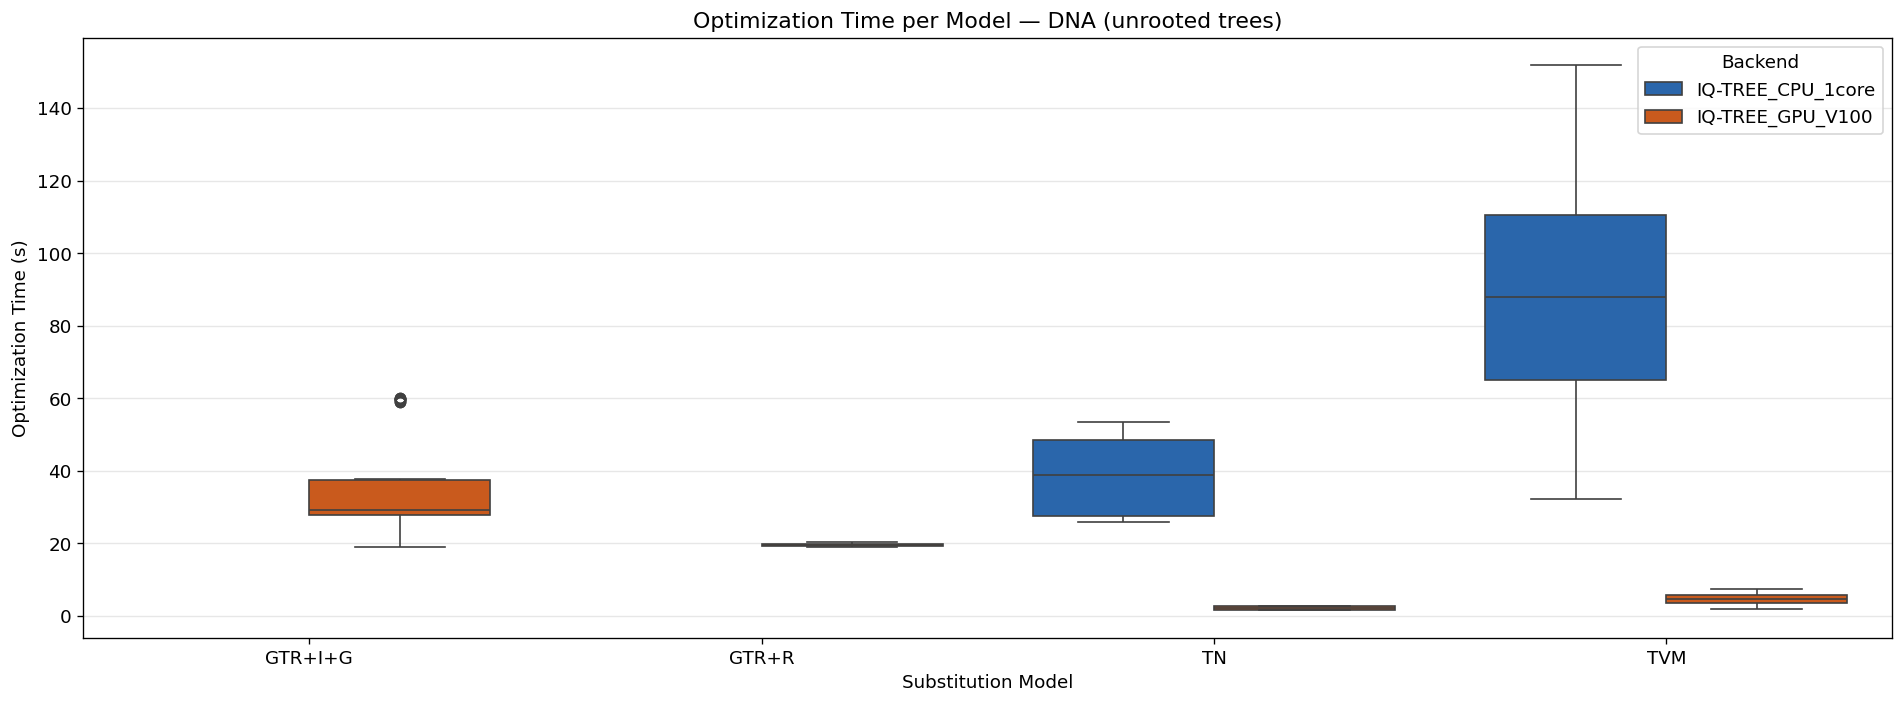

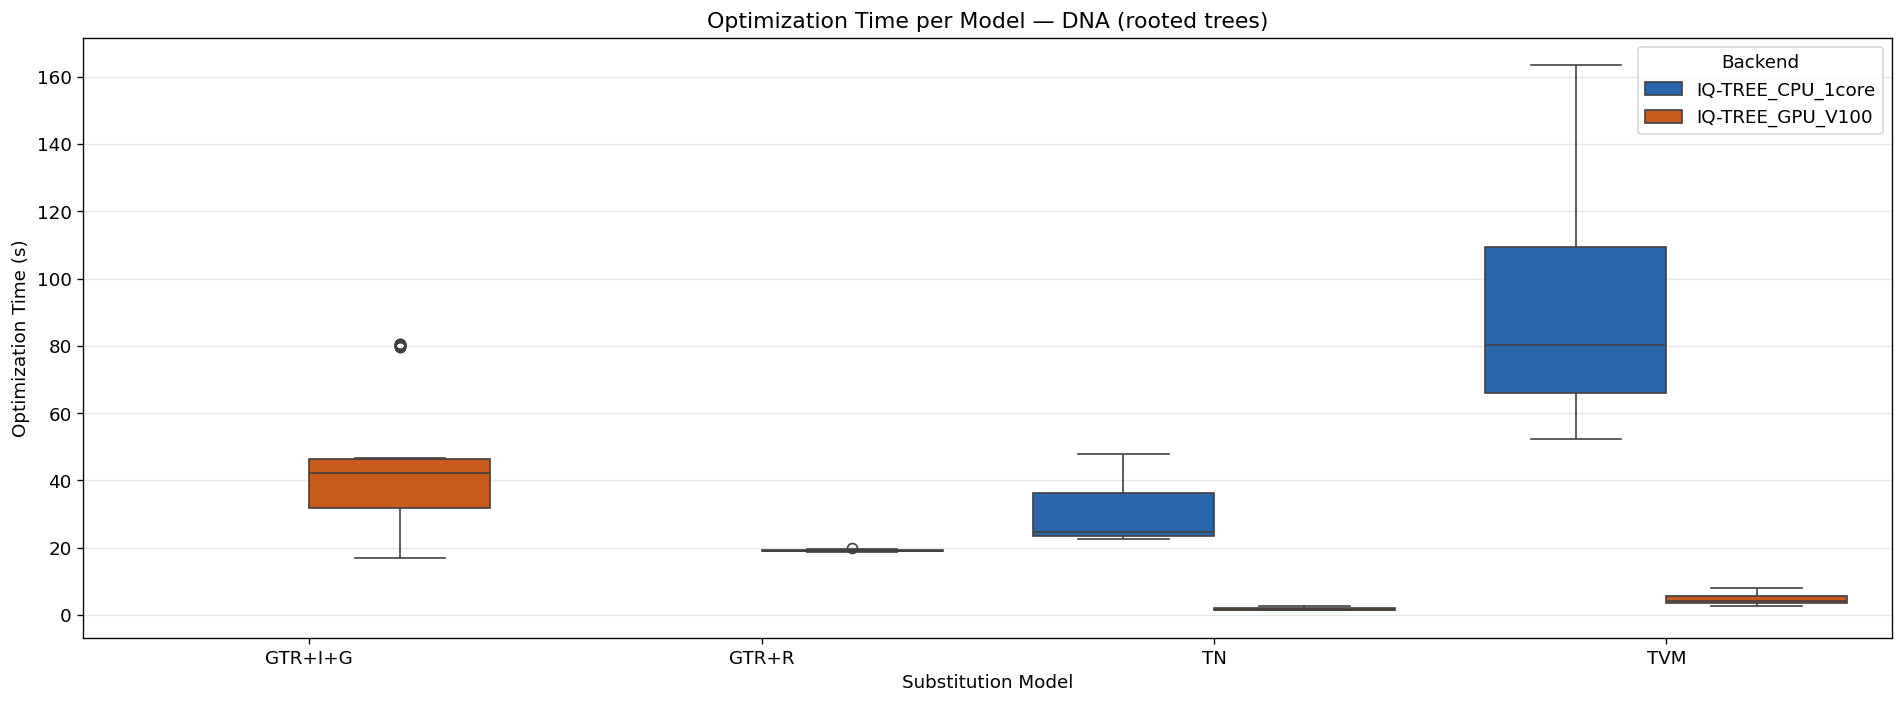

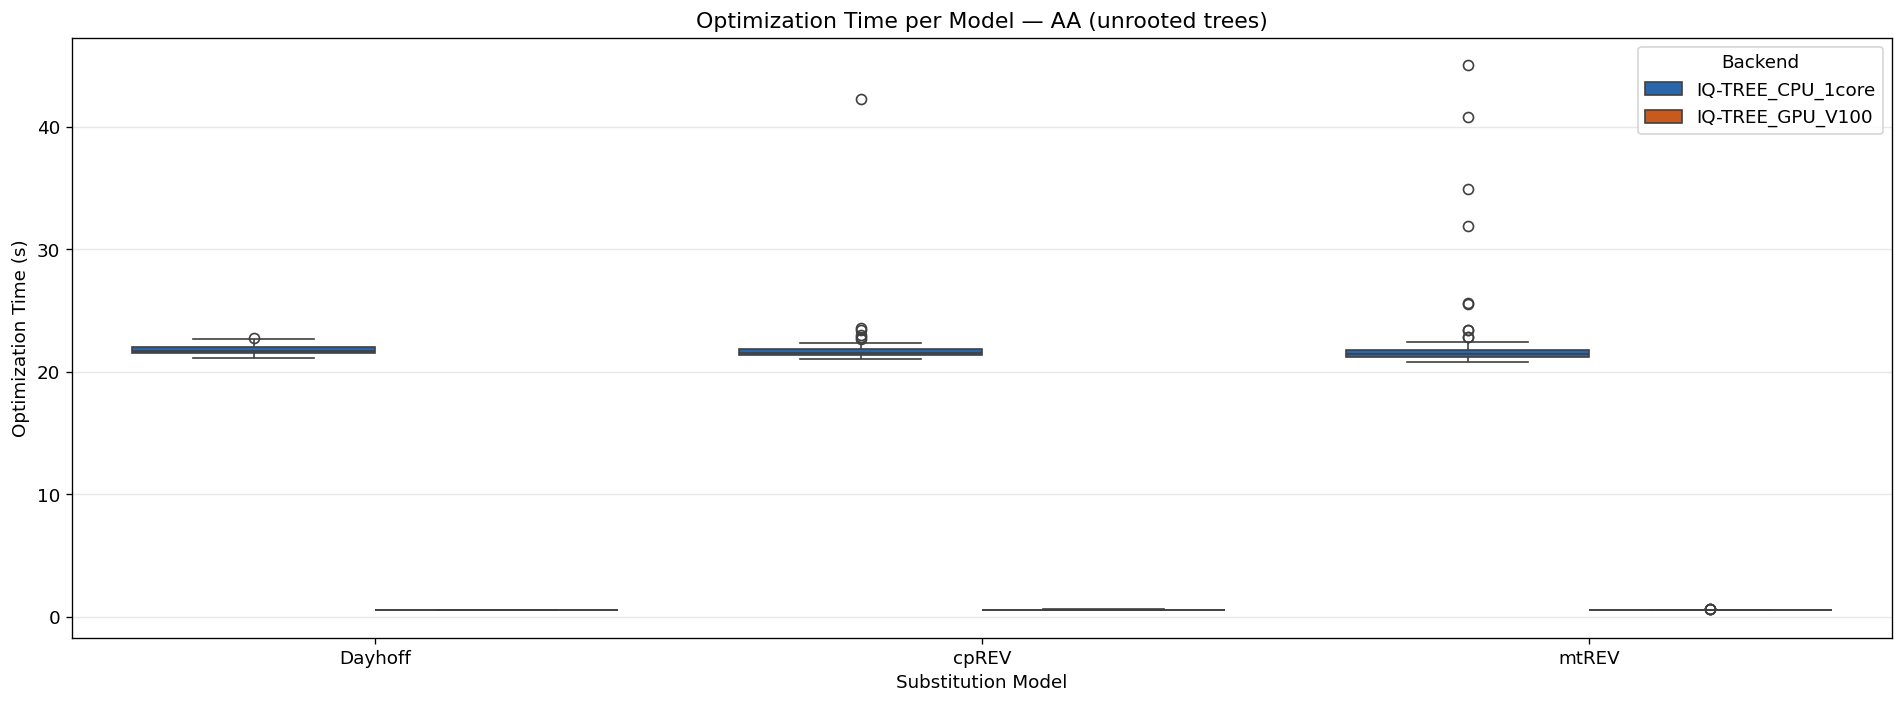

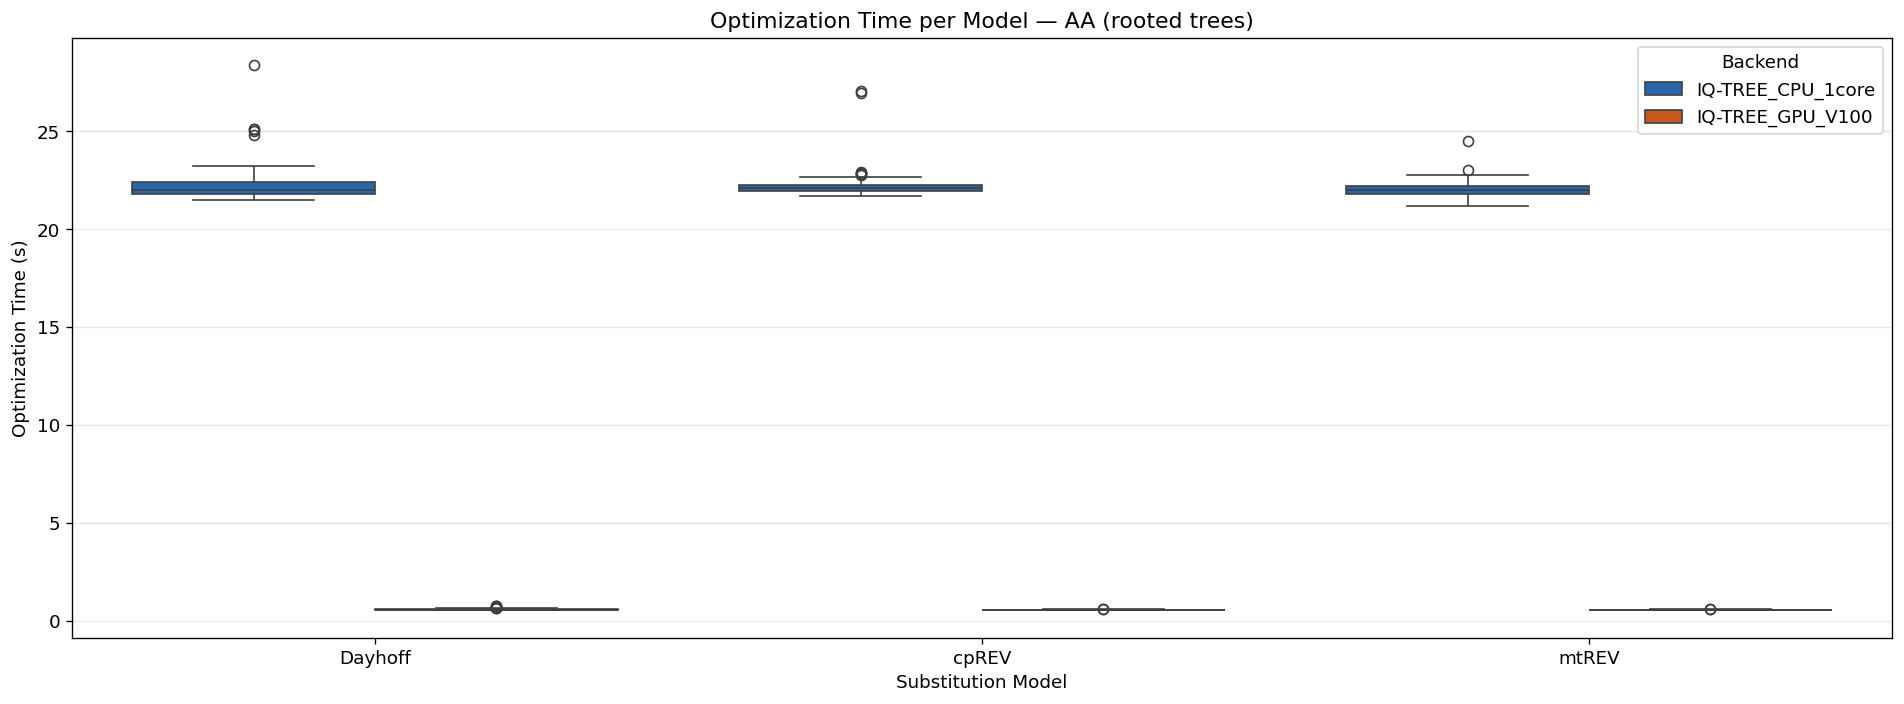

In [6]:
def plot_opt_time_by_model(df, data_type, tree_type, figsize=(16, 6), path=""):
    """Boxplot of optimization time per model, grouped by backend."""
    subset = df[(df['data_type'] == data_type) & (df['tree_type'] == tree_type)].copy()
    present_backends = [b for b in BACKEND_ORDER if b in subset['backend'].unique()]

    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=subset, x='model', y='opt_time', hue='backend',
                hue_order=present_backends,
                palette=BACKEND_PALETTE, ax=ax)

    ax.set_title(f'Optimization Time per Model — {data_type} ({tree_type} trees)')
    ax.set_xlabel('Substitution Model')
    ax.set_ylabel('Optimization Time (s)')
    ax.legend(title='Backend', loc='upper right')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

for dt in ['DNA', 'AA']:
    for tt in ['unrooted', 'rooted']:
        plot_opt_time_by_model(df, dt, tt, path=f"{cwd}/opt_time_{dt}_{tt}.png")

# 4. Wall-clock Time Analysis

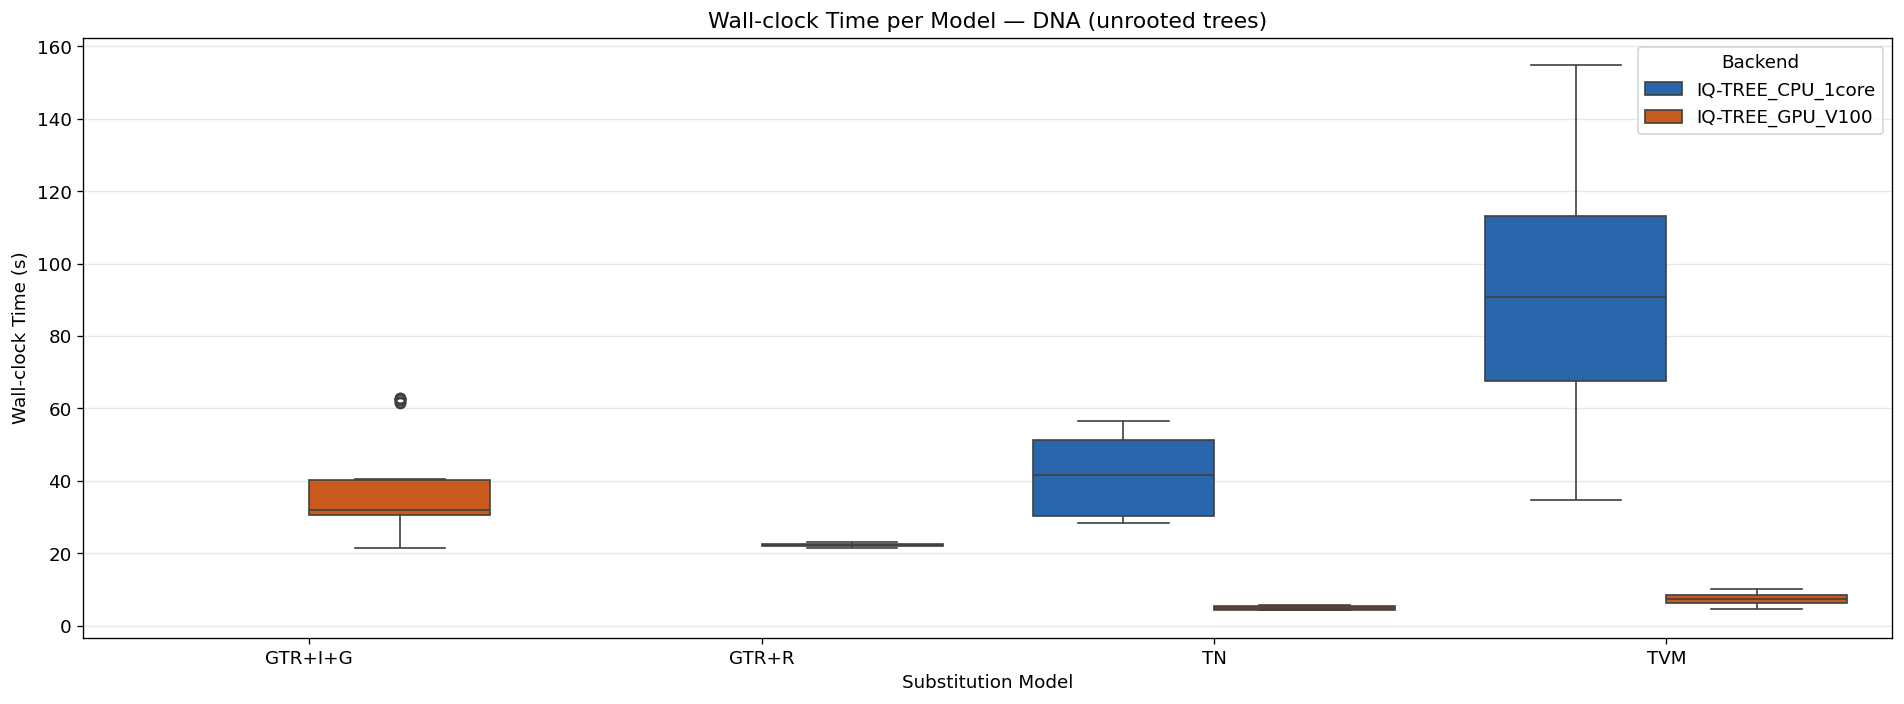

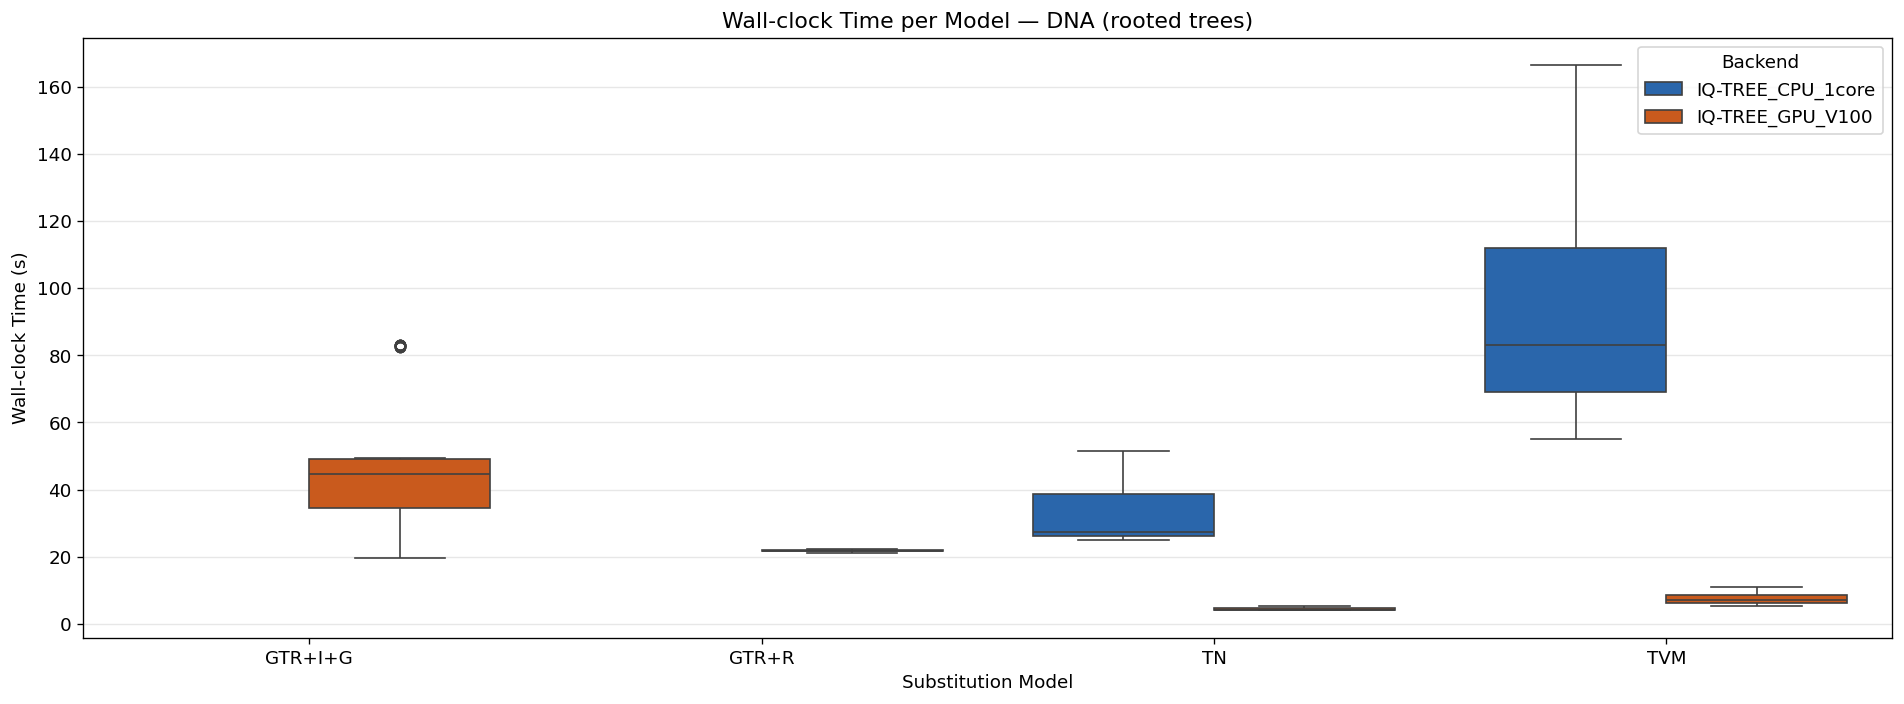

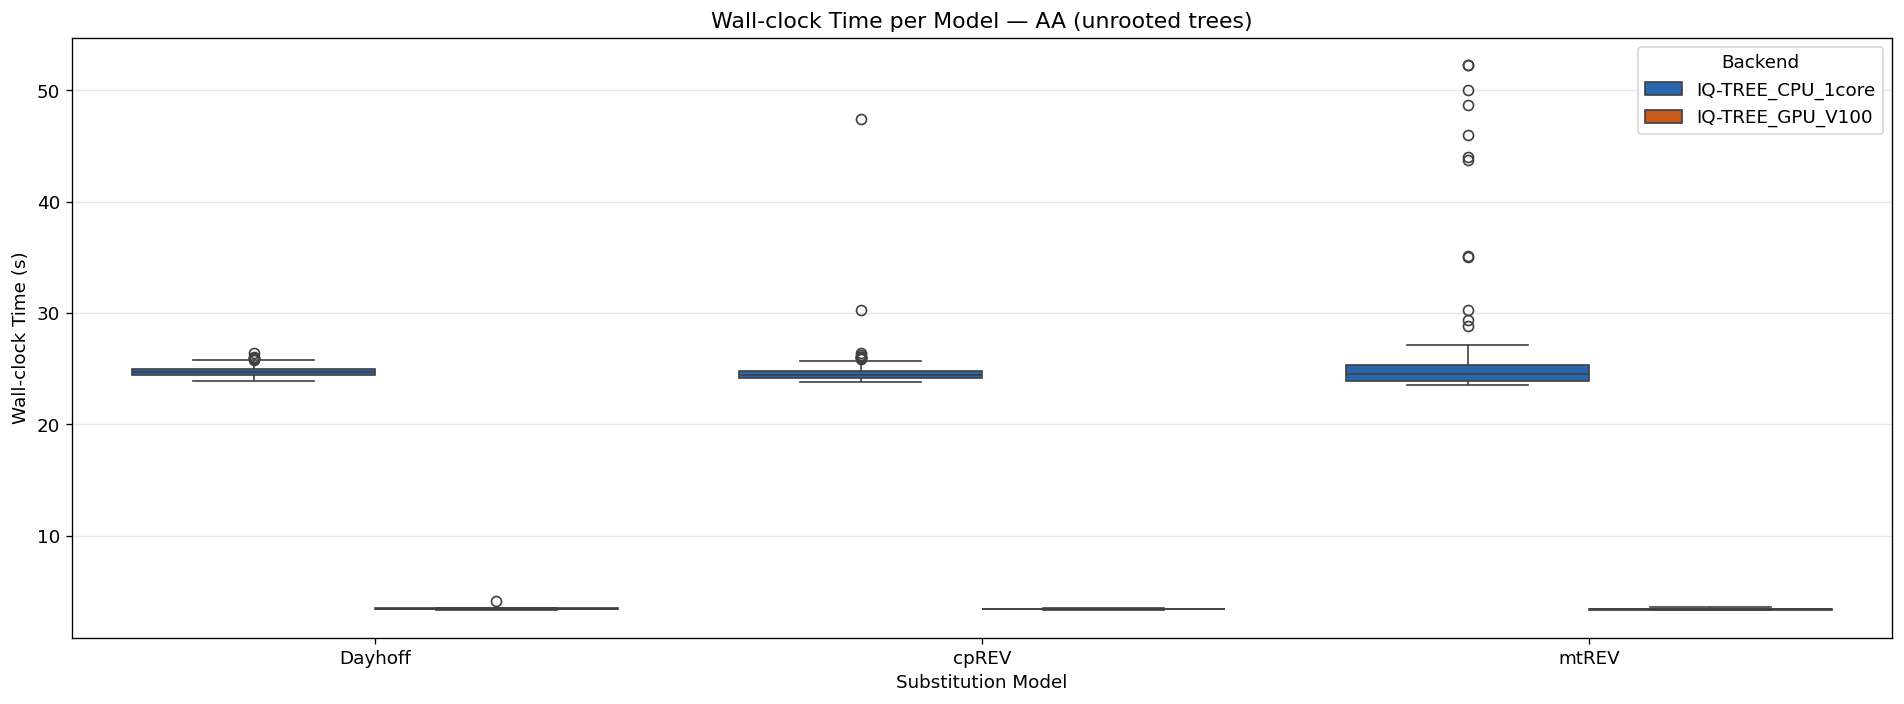

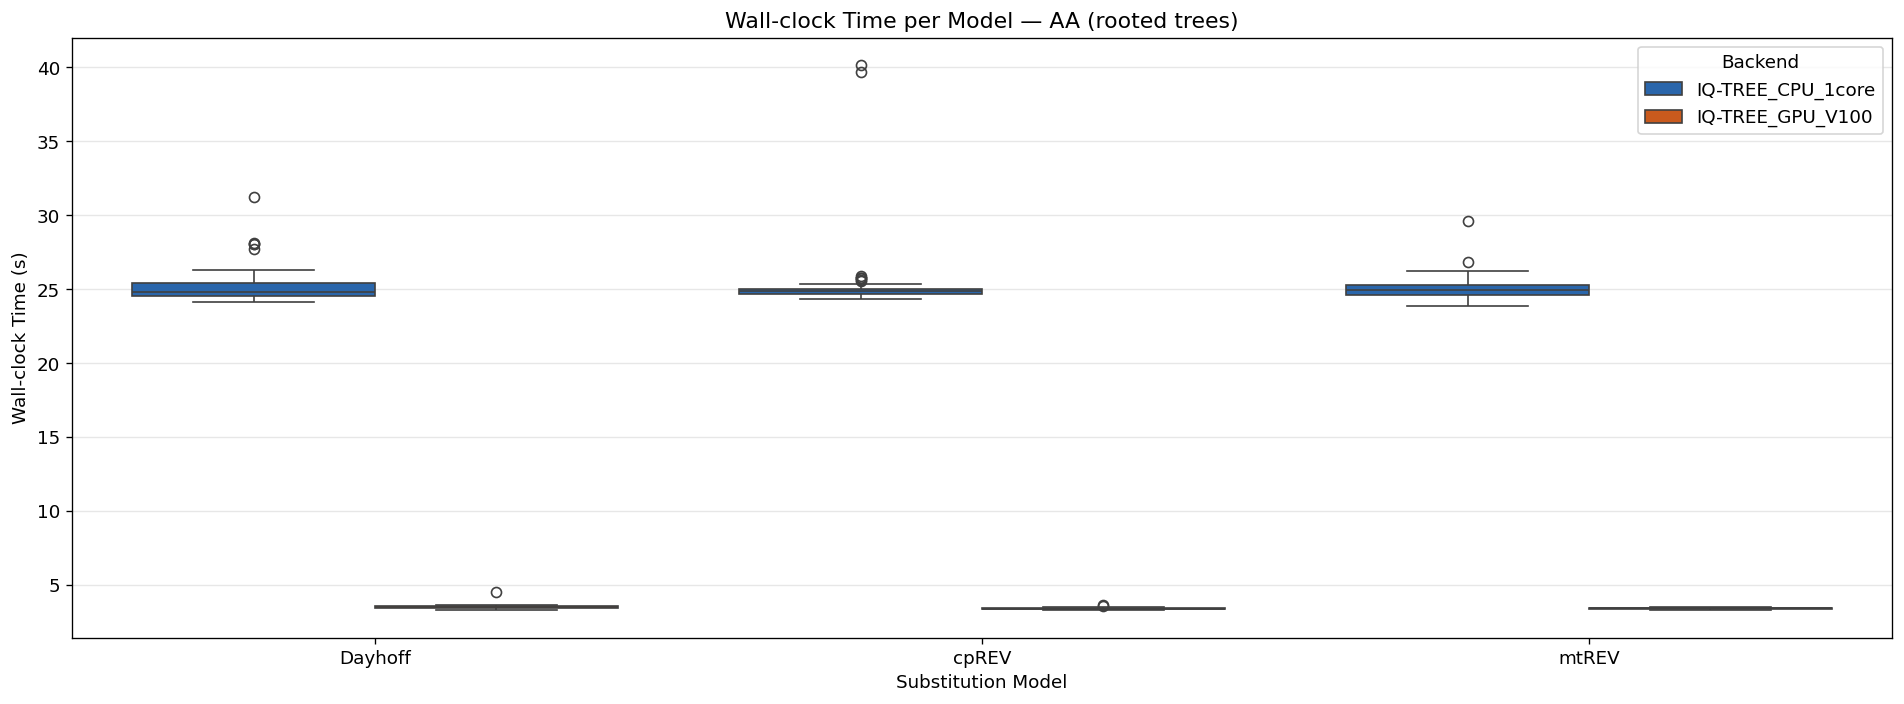

In [7]:
def plot_wallclock_by_model(df, data_type, tree_type, figsize=(16, 6), path=""):
    """Boxplot of wall-clock time per model, grouped by backend."""
    subset = df[(df['data_type'] == data_type) & (df['tree_type'] == tree_type)].copy()
    present_backends = [b for b in BACKEND_ORDER if b in subset['backend'].unique()]

    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=subset, x='model', y='wallclock_time', hue='backend',
                hue_order=present_backends,
                palette=BACKEND_PALETTE, ax=ax)

    ax.set_title(f'Wall-clock Time per Model — {data_type} ({tree_type} trees)')
    ax.set_xlabel('Substitution Model')
    ax.set_ylabel('Wall-clock Time (s)')
    ax.legend(title='Backend', loc='upper right')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

for dt in ['DNA', 'AA']:
    for tt in ['unrooted', 'rooted']:
        plot_wallclock_by_model(df, dt, tt, path=f"{cwd}/wallclock_{dt}_{tt}.png")

# 5. Mean Time Summary Table

In [8]:
# Mean optimization time per backend per model
print("=== Mean Optimization Time (seconds) ===")
opt_means = df.groupby(['data_type', 'model', 'backend'])['opt_time'].mean().unstack('backend')
opt_means = opt_means[[b for b in BACKEND_ORDER if b in opt_means.columns]]
display(opt_means.round(3))

print("\n=== Mean Wall-clock Time (seconds) ===")
wc_means = df.groupby(['data_type', 'model', 'backend'])['wallclock_time'].mean().unstack('backend')
wc_means = wc_means[[b for b in BACKEND_ORDER if b in wc_means.columns]]
display(wc_means.round(3))

=== Mean Optimization Time (seconds) ===


backend            IQ-TREE_CPU_1core  IQ-TREE_GPU_V100
data_type model                                       
AA        Dayhoff             22.008             0.573
          cpREV               22.042             0.562
          mtREV               22.139             0.561
DNA       GTR+I+G                NaN            39.132
          GTR+R                  NaN            19.362
          TN                  34.530             1.986
          TVM                 90.604             4.689


=== Mean Wall-clock Time (seconds) ===


backend            IQ-TREE_CPU_1core  IQ-TREE_GPU_V100
data_type model                                       
AA        Dayhoff             24.915             3.466
          cpREV               25.014             3.401
          mtREV               25.775             3.400
DNA       GTR+I+G                NaN            41.792
          GTR+R                  NaN            21.989
          TN                  37.187             4.738
          TVM                 93.349             7.487

# 6. Speedup Analysis (GPU vs CPU 1-core)

Only models where both VANILA and OPENACC completed are included:  
- AA: Dayhoff, mtREV, cpREV  
- DNA: TN, TVM  

GTR+R and GTR+I+G are excluded from speedup (VANILA failed).

In [9]:
def compute_speedup_vs_gpu(df, ref_backend='IQ-TREE_CPU_1core', time_col='opt_time'):
    """Compute speedup = ref_time / GPU_time for matched runs."""
    ref = df[df['backend'] == ref_backend].copy()
    gpu = df[df['backend'] == 'IQ-TREE_GPU_V100'].copy()

    merge_keys = ['data_type', 'tree_type', 'model', 'treefile', 'run']
    merged = ref.merge(gpu, on=merge_keys, suffixes=('_ref', '_gpu'))

    merged['speedup_opt']       = merged['opt_time_ref']       / merged['opt_time_gpu']
    merged['speedup_wallclock'] = merged['wallclock_time_ref'] / merged['wallclock_time_gpu']
    merged['ref_backend'] = ref_backend

    return merged

speedup_1core = compute_speedup_vs_gpu(df, 'IQ-TREE_CPU_1core')
print(f"Speedup records (CPU 1-core vs GPU): {len(speedup_1core)}")
print("Models with speedup data:")
print(speedup_1core.groupby(['data_type', 'model']).size())

Speedup records (CPU 1-core vs GPU): 10000
Models with speedup data:
data_type  model  
AA         Dayhoff    2000
           cpREV      2000
           mtREV      2000
DNA        TN         2000
           TVM        2000
dtype: int64


In [10]:
# Summary speedup table
print("=== Optimization Time Speedup: GPU vs CPU 1-core ===")
summary_1core = speedup_1core.groupby(['data_type', 'model'])['speedup_opt'].agg(
    ['mean', 'median', 'min', 'max', 'std']
).round(2)
display(summary_1core)

print("\n=== Wall-clock Speedup: GPU vs CPU 1-core ===")
summary_wc = speedup_1core.groupby(['data_type', 'model'])['speedup_wallclock'].agg(
    ['mean', 'median', 'min', 'max', 'std']
).round(2)
display(summary_wc)

=== Optimization Time Speedup: GPU vs CPU 1-core ===


mean  median    min    max   std
data_type model                                     
AA        Dayhoff  38.53   38.81  27.76  49.54  2.08
          cpREV    39.28   39.20  34.61  74.95  2.94
          mtREV    39.53   39.07  33.07  81.16  4.43
DNA       TN       17.20   17.26  15.11  20.32  1.03
          TVM      19.17   19.08  16.59  26.41  0.92


=== Wall-clock Speedup: GPU vs CPU 1-core ===


mean  median   min    max   std
data_type model                                    
AA        Dayhoff   7.20    7.19  5.36   9.19  0.30
          cpREV     7.36    7.27  6.68  14.18  0.67
          mtREV     7.58    7.28  6.65  15.76  1.34
DNA       TN        7.72    7.88  5.87  10.38  1.30
          TVM      12.11   11.94  7.37  17.55  1.82

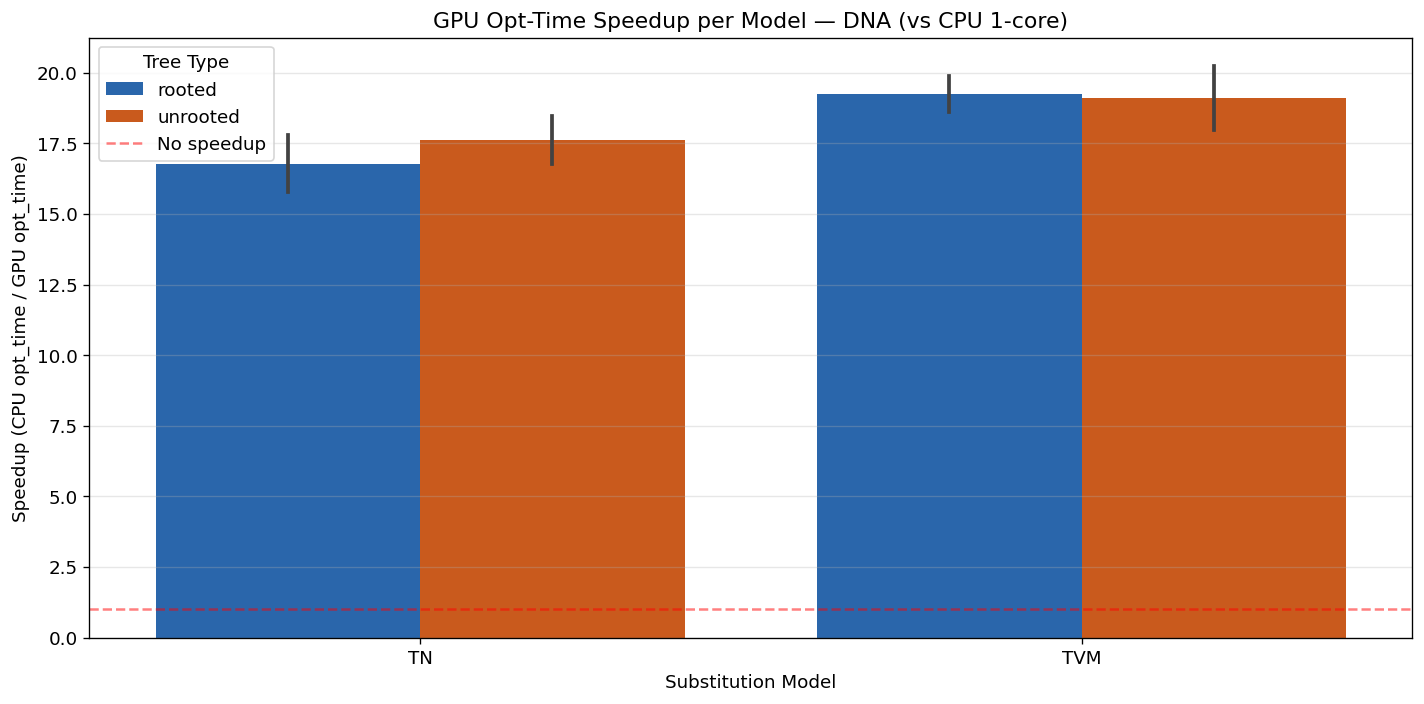

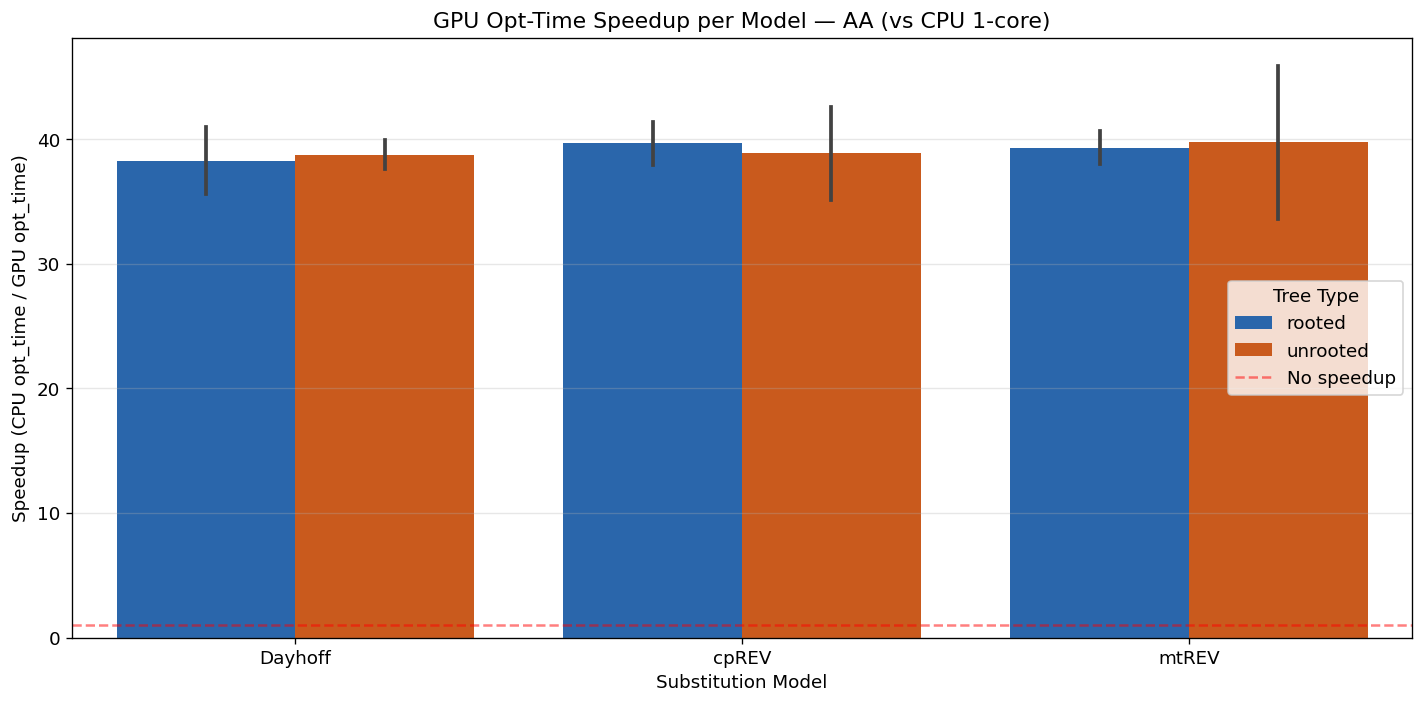

In [11]:
# Speedup bar plot: GPU vs 1-core CPU, per model, split by tree type
def plot_speedup_by_model_opt(speedup_df, data_type, figsize=(12, 6), path=""):
    subset = speedup_df[speedup_df['data_type'] == data_type]
    if len(subset) == 0:
        print(f"No speedup data for {data_type}")
        return

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=subset, x='model', y='speedup_opt', hue='tree_type',
                palette=['#1565C0', '#E65100'], ax=ax, errorbar='sd')

    ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='No speedup')
    ax.set_title(f'GPU Opt-Time Speedup per Model — {data_type} (vs CPU 1-core)')
    ax.set_xlabel('Substitution Model')
    ax.set_ylabel('Speedup (CPU opt_time / GPU opt_time)')
    ax.legend(title='Tree Type')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

plot_speedup_by_model_opt(speedup_1core, 'DNA', path=f"{cwd}/speedup_DNA.png")
plot_speedup_by_model_opt(speedup_1core, 'AA', path=f"{cwd}/speedup_AA.png")

In [12]:
# Combined speedup overview: mean speedup per model
print("=== Combined Speedup Overview (Mean Opt Time Speedup vs GPU) ===")
combined_speedup = speedup_1core.groupby(['data_type', 'model'])['speedup_opt'].mean().rename('GPU vs 1-core').unstack(level=0).T
combined_speedup = speedup_1core.groupby(['data_type', 'model'])['speedup_opt'].mean().unstack('model').rename_axis(None, axis=1)
# pivot properly
cs = speedup_1core.groupby(['data_type', 'model'])['speedup_opt'].mean().rename('GPU vs 1-core').reset_index()
combined_speedup_pivot = cs.pivot(index='data_type', columns='model', values='GPU vs 1-core').round(2)
display(combined_speedup_pivot)

=== Combined Speedup Overview (Mean Opt Time Speedup vs GPU) ===


model,Dayhoff,TN,TVM,cpREV,mtREV
data_type,,,,,
AA,38.53,NaN,NaN,39.28,39.53
DNA,NaN,17.2,19.17,NaN,NaN


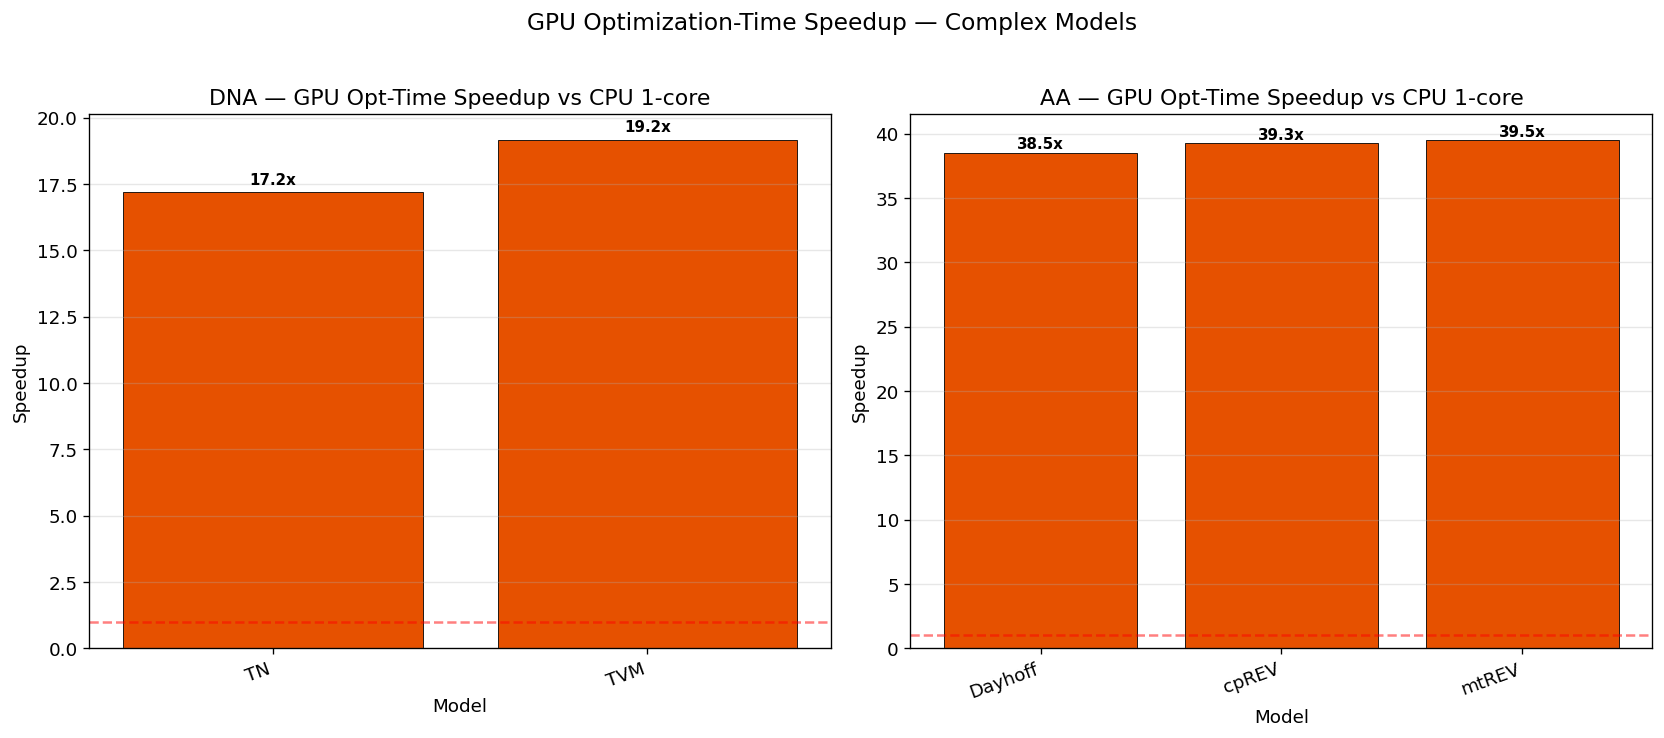

In [13]:
# Speedup bar plot — side-by-side DNA + AA
dna_speedup = speedup_1core[speedup_1core['data_type'] == 'DNA'].groupby('model')['speedup_opt'].mean()
aa_speedup  = speedup_1core[speedup_1core['data_type'] == 'AA'].groupby('model')['speedup_opt'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, speedup_s, dt in [(ax1, dna_speedup, 'DNA'), (ax2, aa_speedup, 'AA')]:
    if len(speedup_s) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', transform=ax.transAxes)
        ax.set_title(f'{dt}')
        continue
    models = speedup_s.index.tolist()
    x = np.arange(len(models))
    bars = ax.bar(x, speedup_s.values, color='#E65100', edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, speedup_s.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}x', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha='right')
    ax.set_title(f'{dt} — GPU Opt-Time Speedup vs CPU 1-core')
    ax.set_xlabel('Model')
    ax.set_ylabel('Speedup')
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('GPU Optimization-Time Speedup — Complex Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/speedup_bar_final.png", bbox_inches='tight')
plt.show()

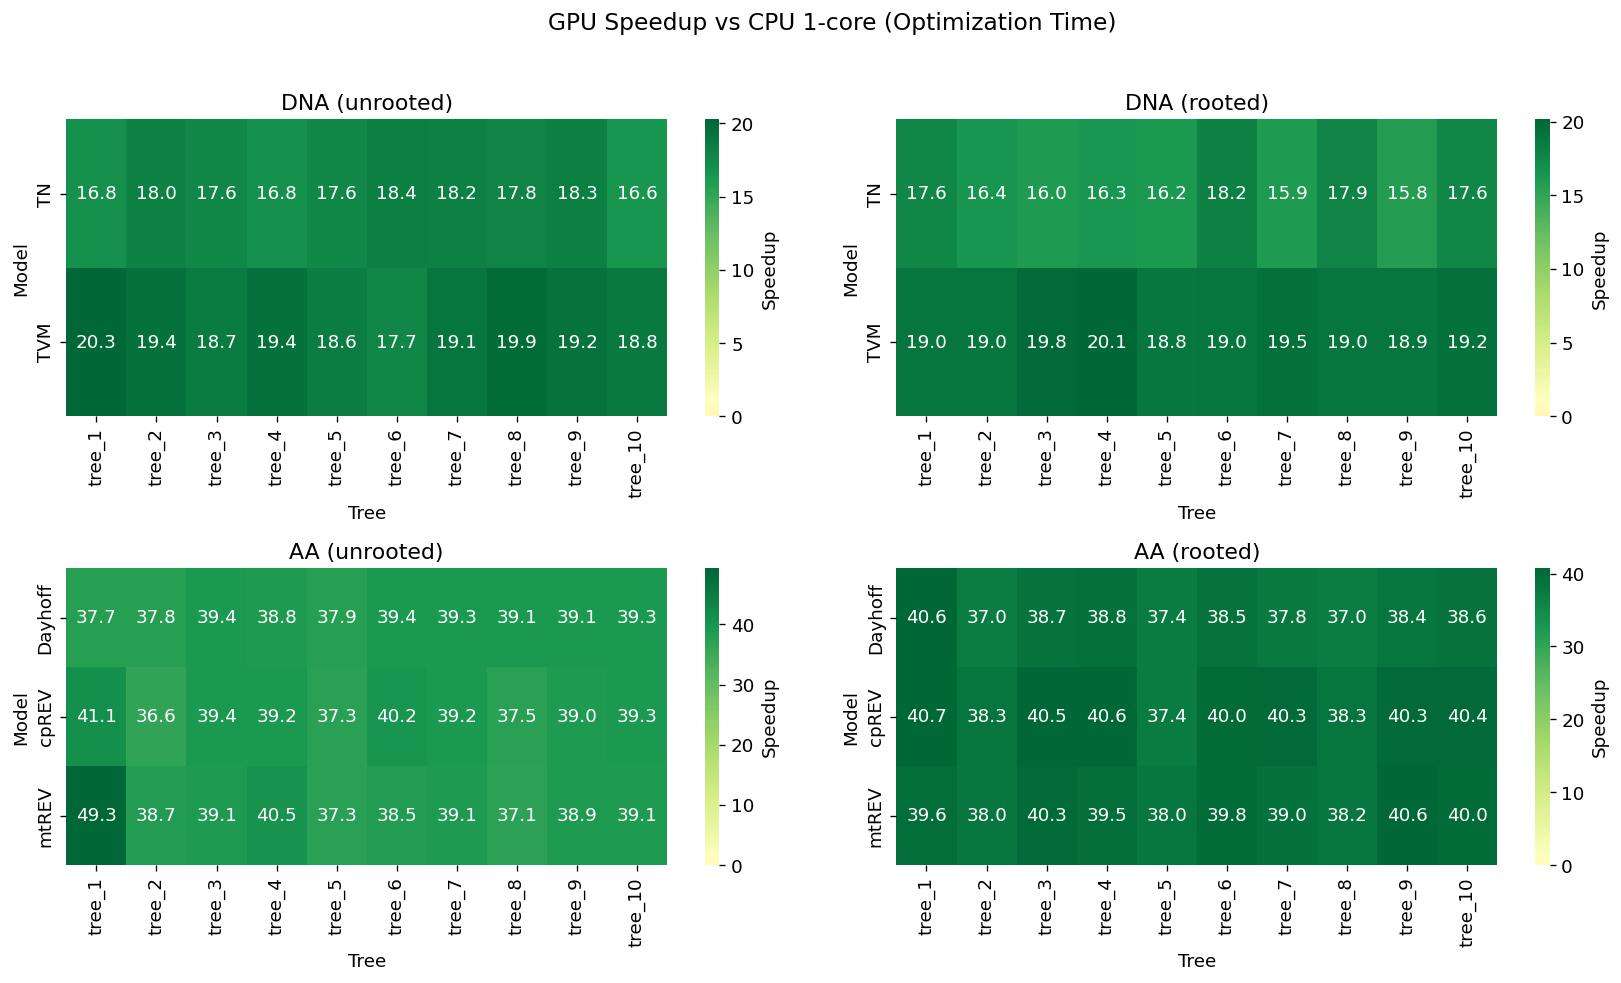

In [14]:
# Speedup heatmap: GPU vs 1-core, per model per tree
def plot_speedup_heatmap(speedup_df, speedup_col='speedup_opt', figsize=(14, 8), path=""):
    """Heatmap of mean speedup per (model, tree) — 2x2 grid."""
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    combos = [
        ('DNA', 'unrooted', axes[0, 0]),
        ('DNA', 'rooted',   axes[0, 1]),
        ('AA',  'unrooted', axes[1, 0]),
        ('AA',  'rooted',   axes[1, 1]),
    ]

    for data_type, tree_type, ax in combos:
        subset = speedup_df[(speedup_df['data_type'] == data_type) &
                            (speedup_df['tree_type'] == tree_type)]
        if len(subset) == 0:
            ax.set_title(f'{data_type} ({tree_type}) — No data')
            ax.axis('off')
            continue

        pivot = subset.groupby(['model', 'treefile'])[speedup_col].mean().unstack()
        pivot = pivot[sorted(pivot.columns, key=lambda x: int(re.search(r'\d+', x).group()))]

        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=1,
                    ax=ax, cbar_kws={'label': 'Speedup'}, vmin=0)
        ax.set_title(f'{data_type} ({tree_type})')
        ax.set_xlabel('Tree')
        ax.set_ylabel('Model')

    plt.suptitle('GPU Speedup vs CPU 1-core (Optimization Time)', fontsize=14, y=1.02)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

plot_speedup_heatmap(speedup_1core, path=f"{cwd}/speedup_heatmap.png")

# 7. GPU-only timing for models without CPU baseline

For DNA GTR+R and GTR+I+G, only OPENACC (GPU) completed. 
We report GPU opt_time directly.

=== GPU-only models (no CPU baseline): DNA GTR+R / GTR+I+G ===


mean  median     min     max     std
model   tree_type                                        
GTR+I+G rooted     43.577  42.159  16.996  80.591  21.124
        unrooted   34.687  29.240  19.008  60.094  13.881
GTR+R   rooted     19.155  19.142  18.682  19.811   0.232
        unrooted   19.567  19.566  18.890  20.273   0.346

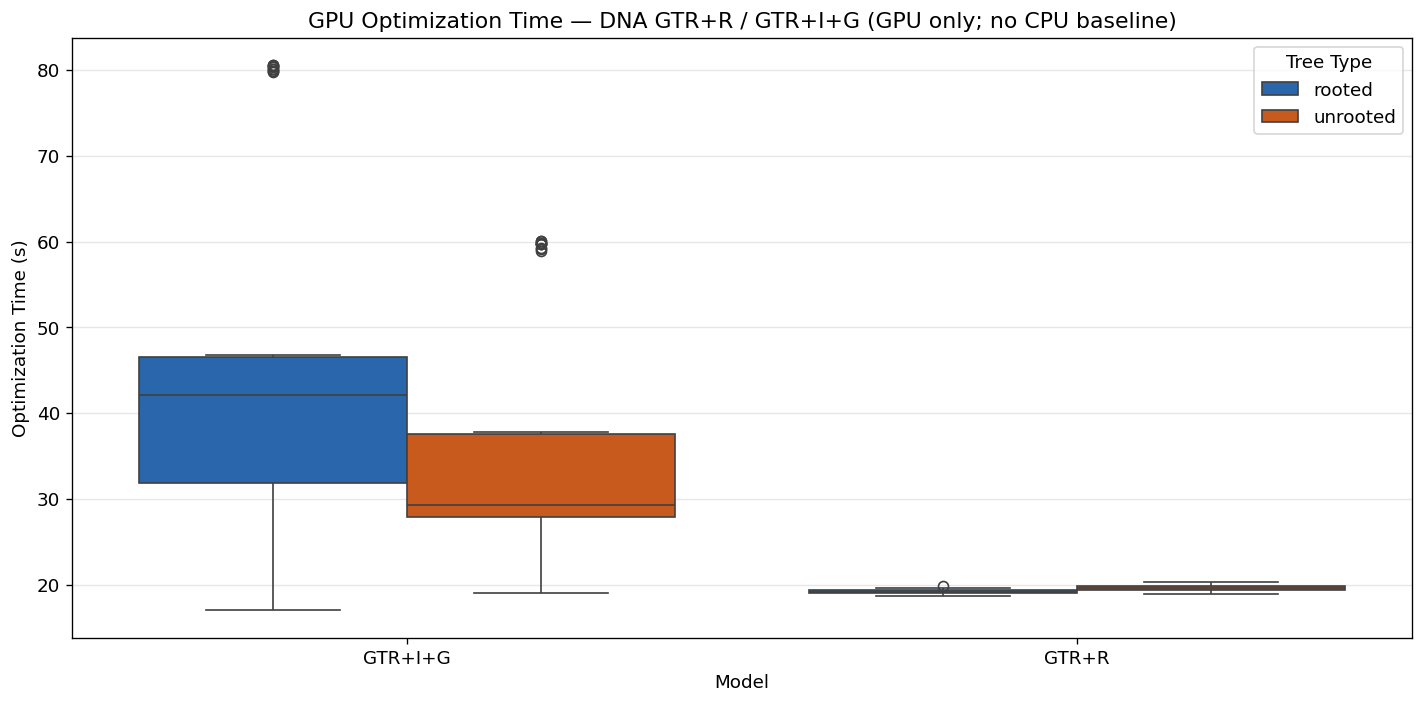

In [15]:
gpu_only_models = ['GTR+R', 'GTR+I+G']
gpu_only = df[(df['data_type'] == 'DNA') & 
               (df['model'].isin(gpu_only_models)) & 
               (df['backend'] == 'IQ-TREE_GPU_V100')]

if len(gpu_only) > 0:
    print("=== GPU-only models (no CPU baseline): DNA GTR+R / GTR+I+G ===")
    gpu_summary = gpu_only.groupby(['model', 'tree_type'])['opt_time'].agg(
        ['mean', 'median', 'min', 'max', 'std']
    ).round(3)
    display(gpu_summary)

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=gpu_only, x='model', y='opt_time', hue='tree_type',
                palette=['#1565C0', '#E65100'], ax=ax)
    ax.set_title('GPU Optimization Time — DNA GTR+R / GTR+I+G (GPU only; no CPU baseline)')
    ax.set_xlabel('Model')
    ax.set_ylabel('Optimization Time (s)')
    ax.legend(title='Tree Type')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{cwd}/gpu_only_DNA_opt_time.png", bbox_inches='tight')
    plt.show()
else:
    print("No GPU-only DNA records found.")

# 8. Per-Tree Runtime Comparison

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_38260/977502804.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


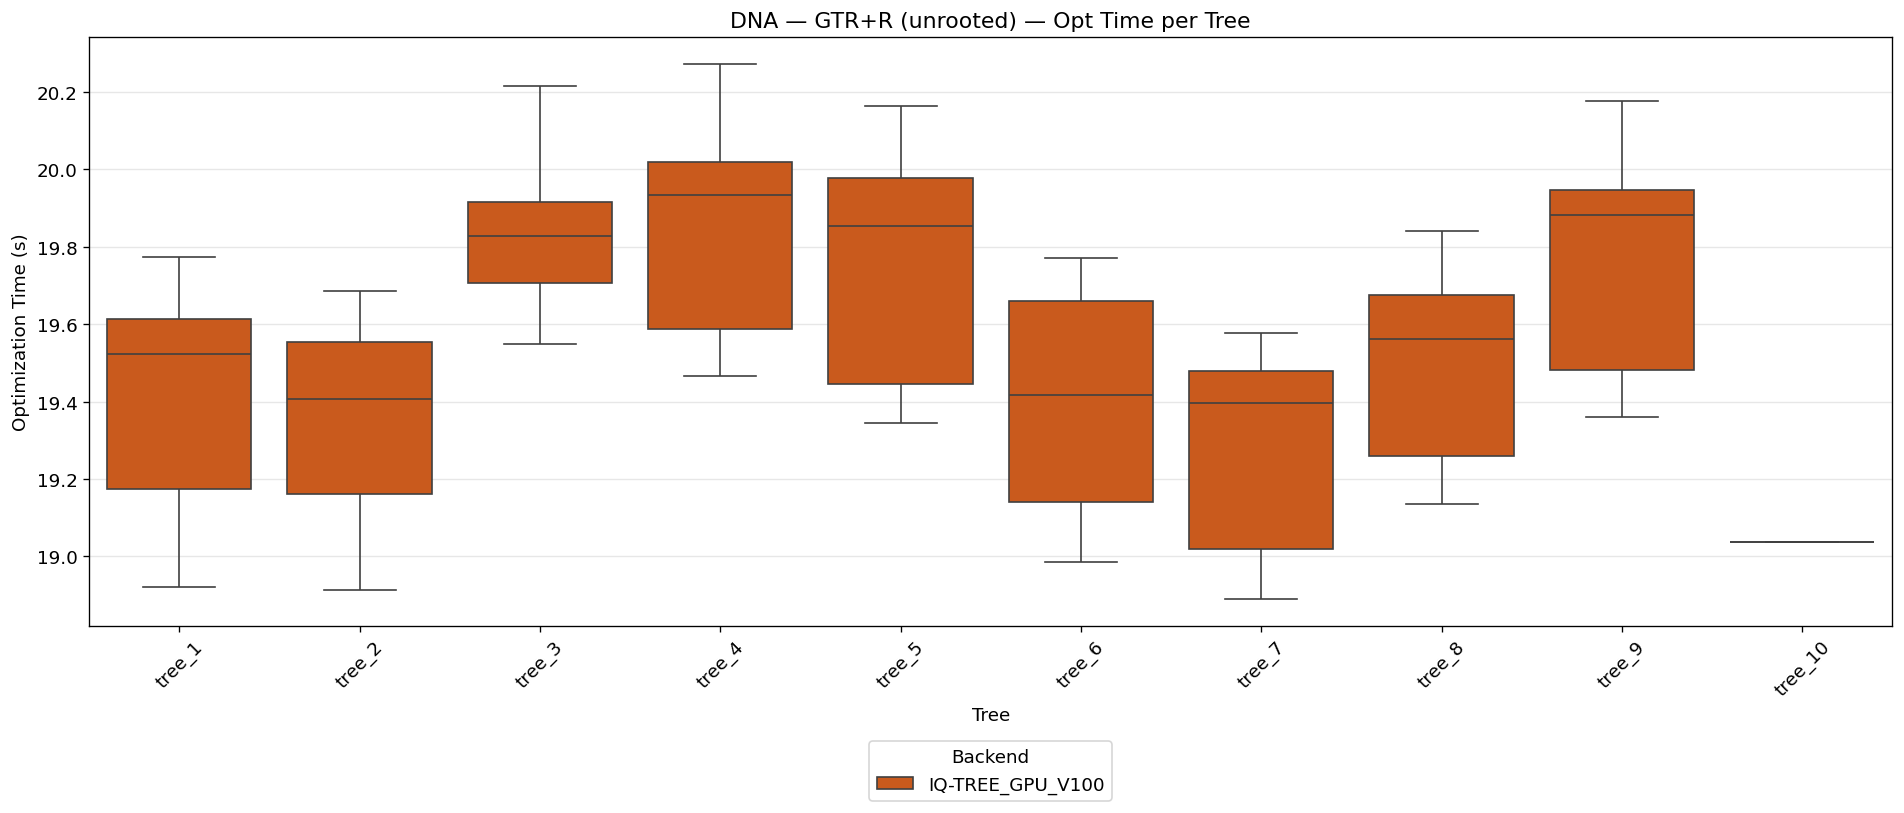

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_38260/977502804.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


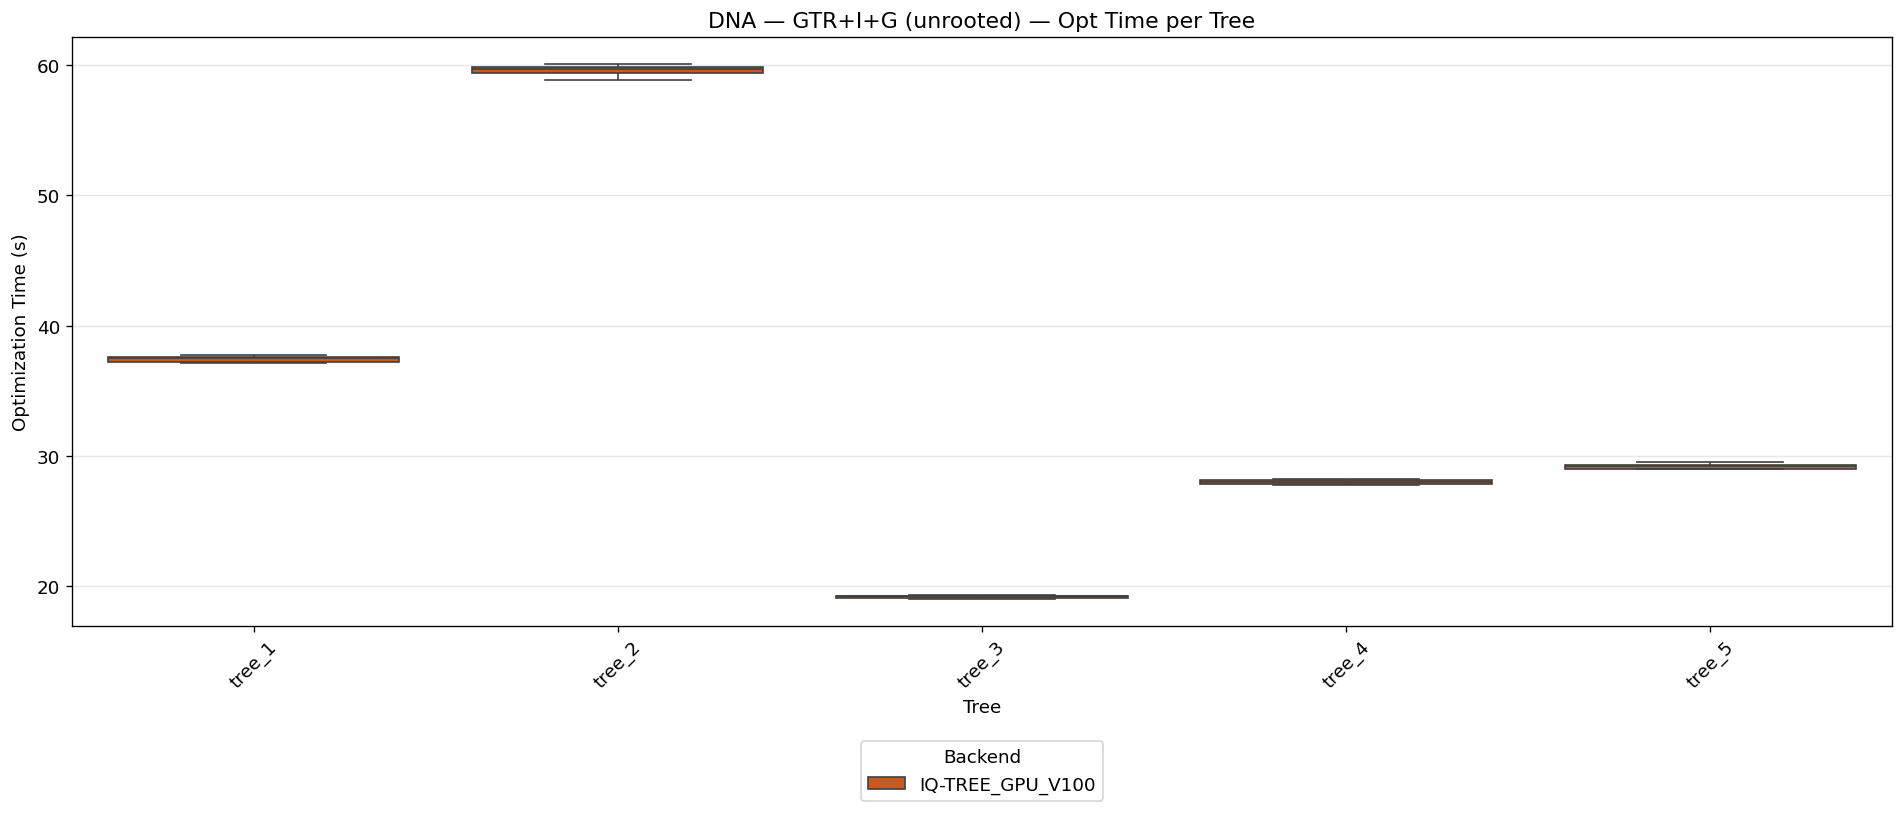

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_38260/977502804.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


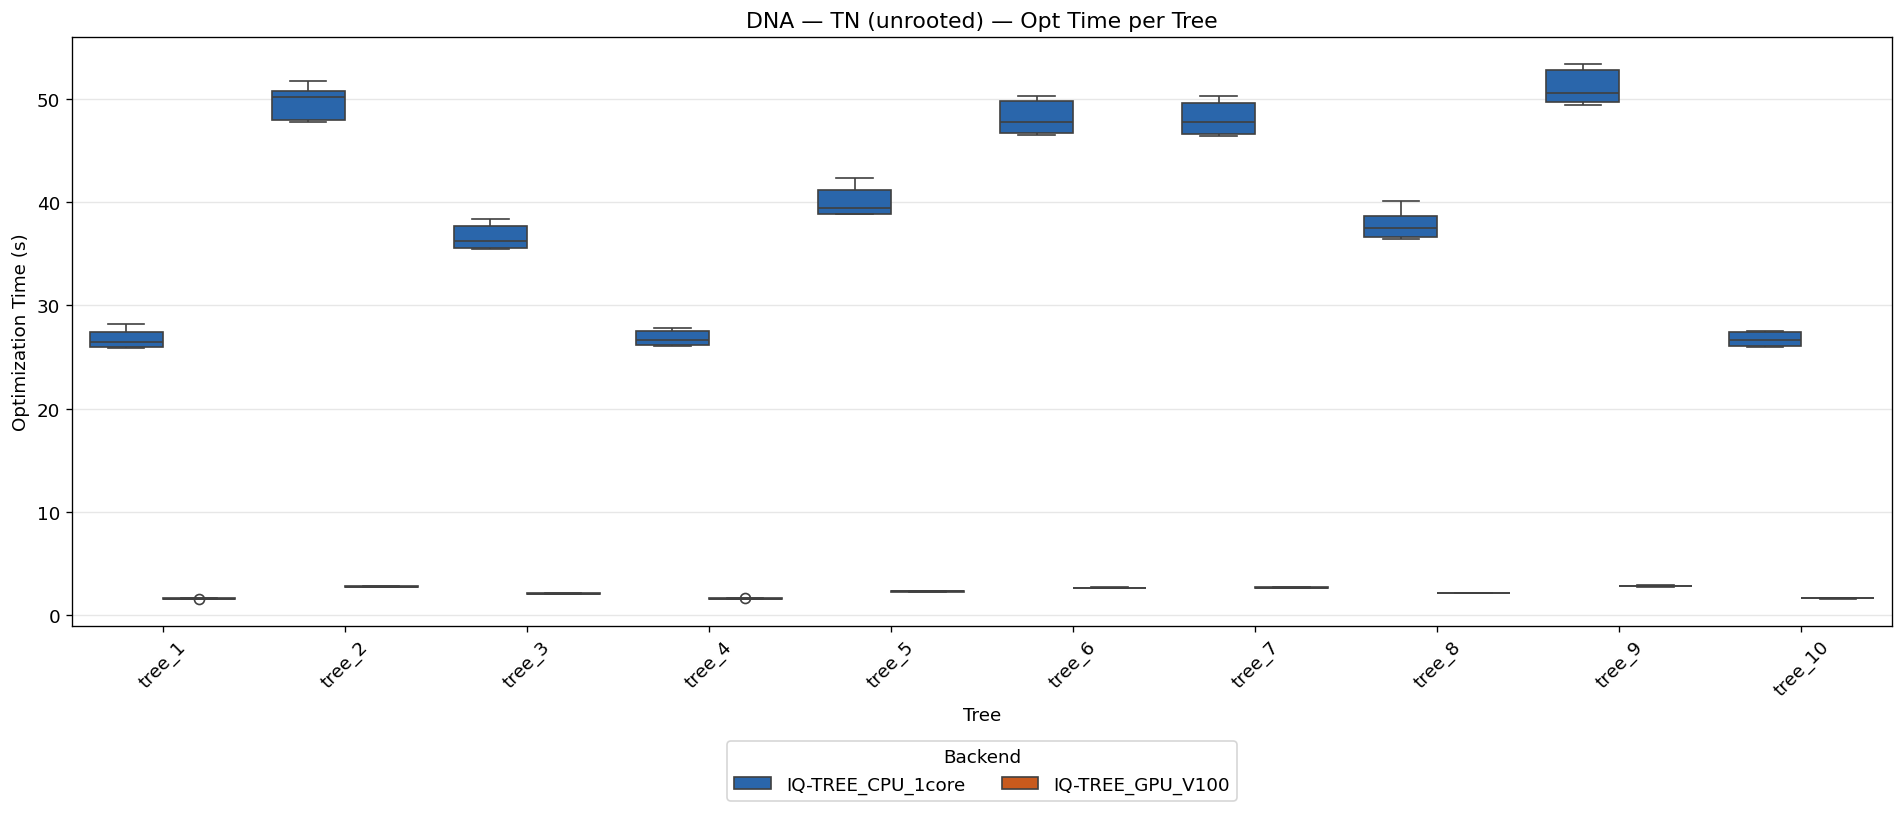

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_38260/977502804.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


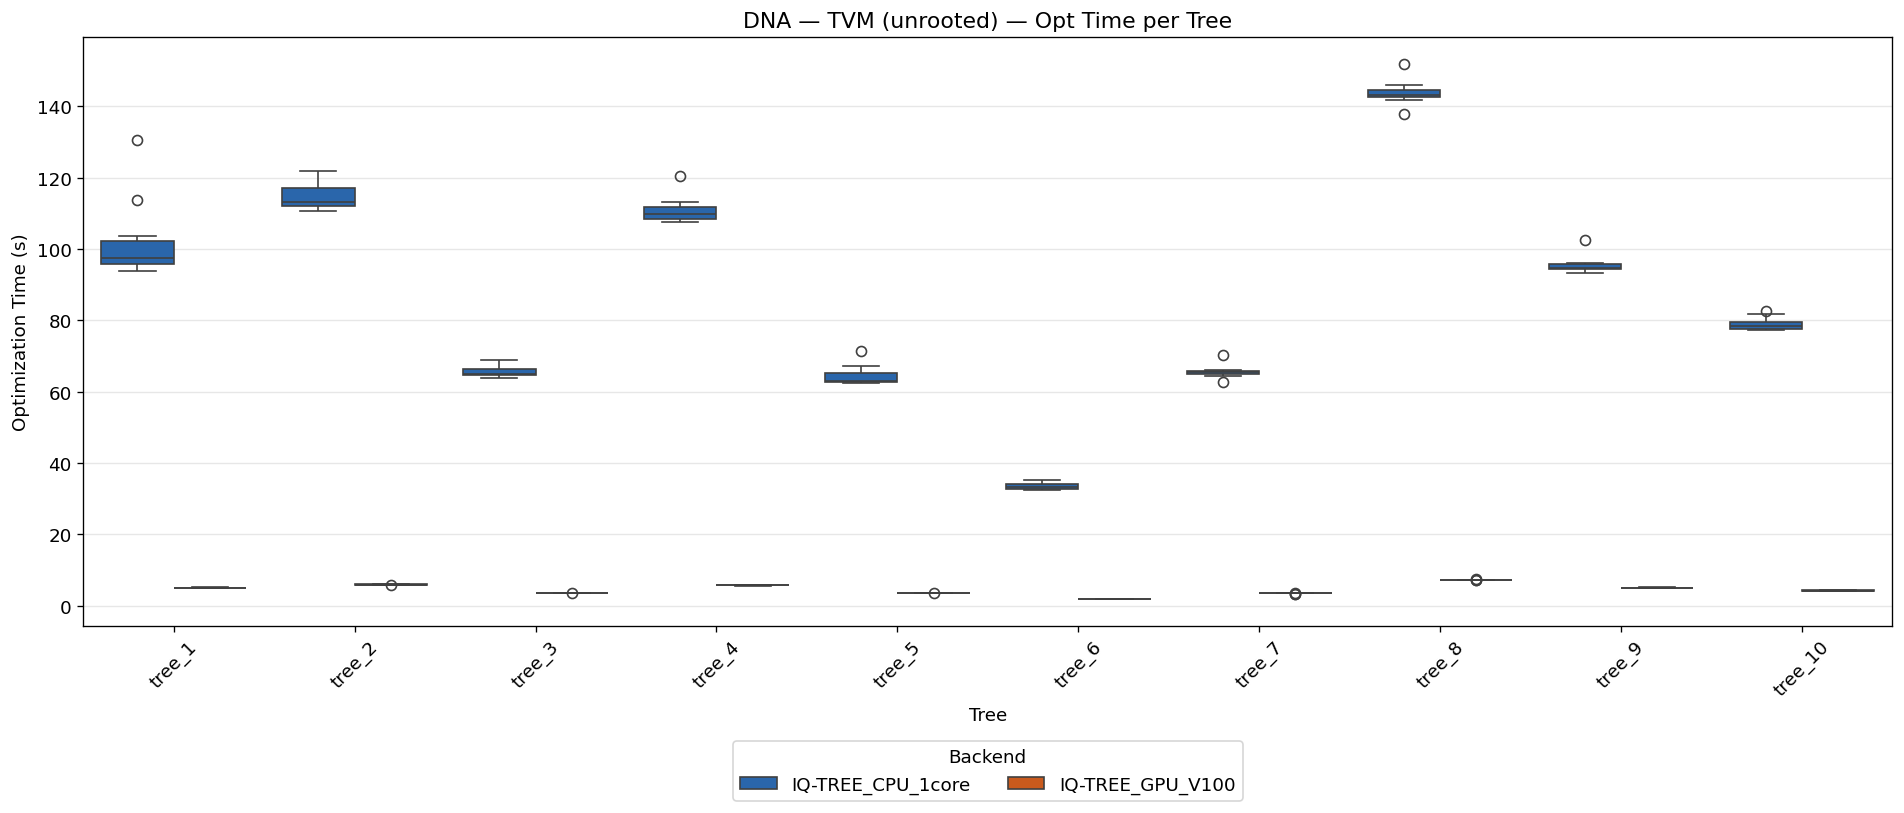

In [16]:
def plot_per_tree_comparison(df, data_type, model, tree_type='unrooted',
                              time_col='opt_time', figsize=(16, 7), path=""):
    """Boxplot of runtime per tree, grouped by backend."""
    subset = df[(df['data_type'] == data_type) &
                (df['model'] == model) &
                (df['tree_type'] == tree_type)].copy()
    if len(subset) == 0:
        print(f"No data for {data_type}/{model}/{tree_type}")
        return

    present_backends = [b for b in BACKEND_ORDER if b in subset['backend'].unique()]
    tree_order = sorted(subset['treefile'].unique(), key=lambda x: int(re.search(r'\d+', x).group()))

    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=subset, x='treefile', y=time_col, hue='backend',
                hue_order=present_backends,
                palette=BACKEND_PALETTE, order=tree_order, ax=ax)

    ax.set_title(f'{data_type} — {model} ({tree_type}) — Opt Time per Tree')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Optimization Time (s)')
    ax.legend(title='Backend', bbox_to_anchor=(0.5, -0.18), loc='upper center', ncol=len(present_backends))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

# DNA models — all 4 models, both backends where available
for model in ['GTR+R', 'GTR+I+G', 'TN', 'TVM']:
    plot_per_tree_comparison(df, 'DNA', model, 'unrooted',
                              path=f"{cwd}/per_tree_DNA_{model.replace('+', '_')}_unrooted.png")

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_38260/977502804.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


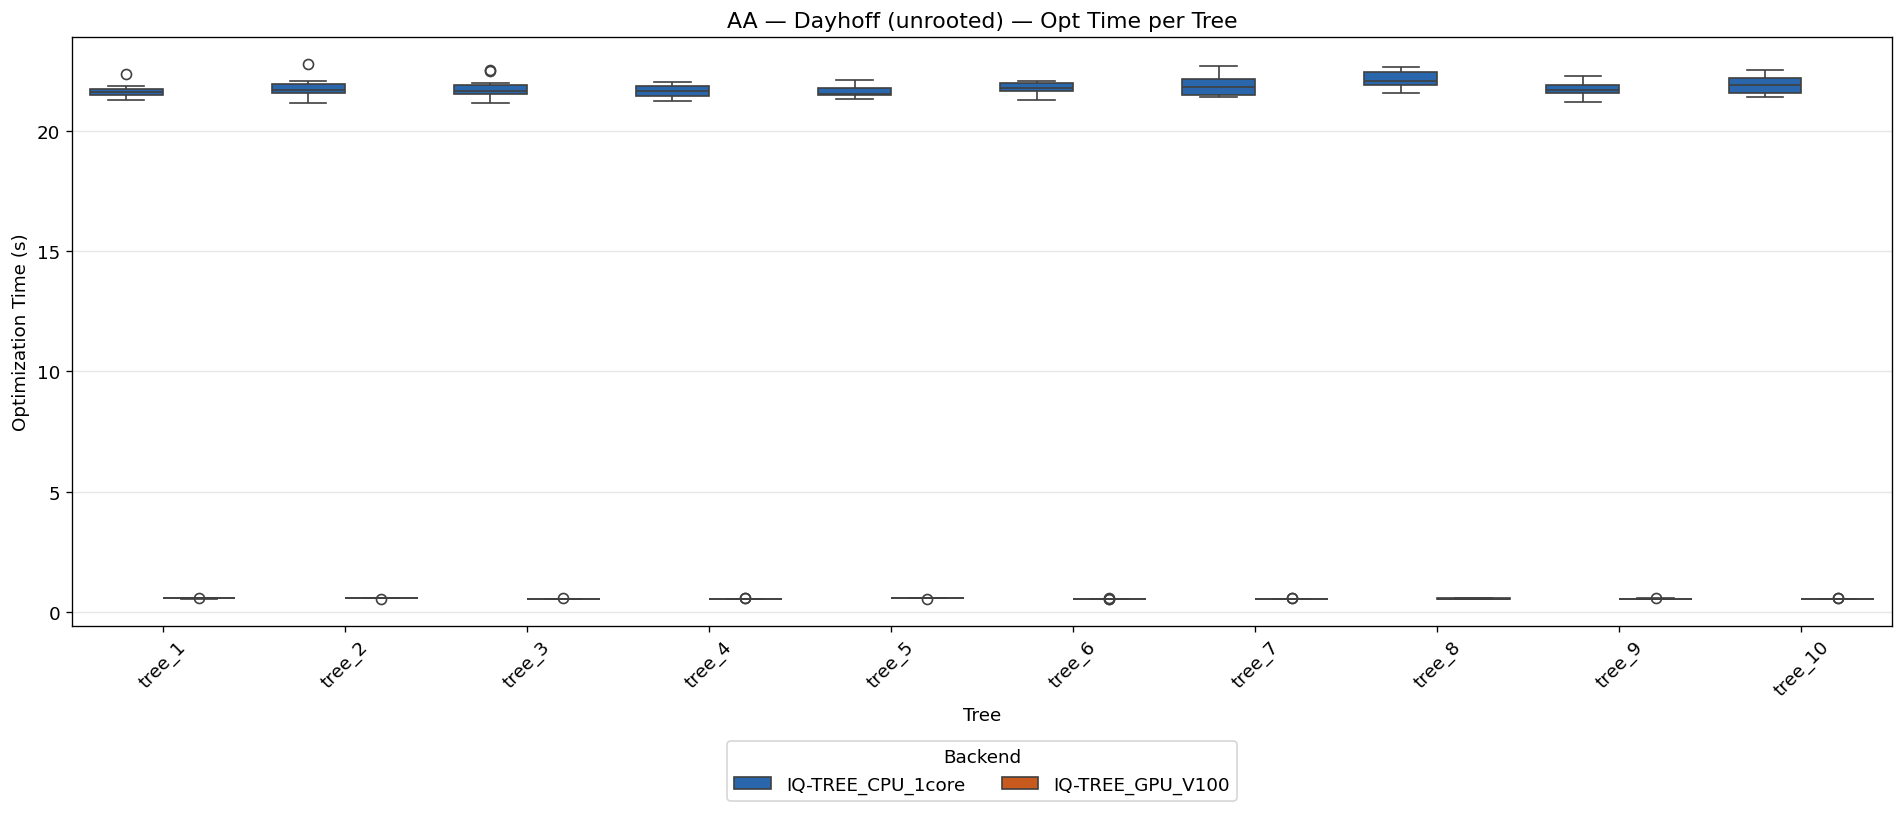

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_38260/977502804.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


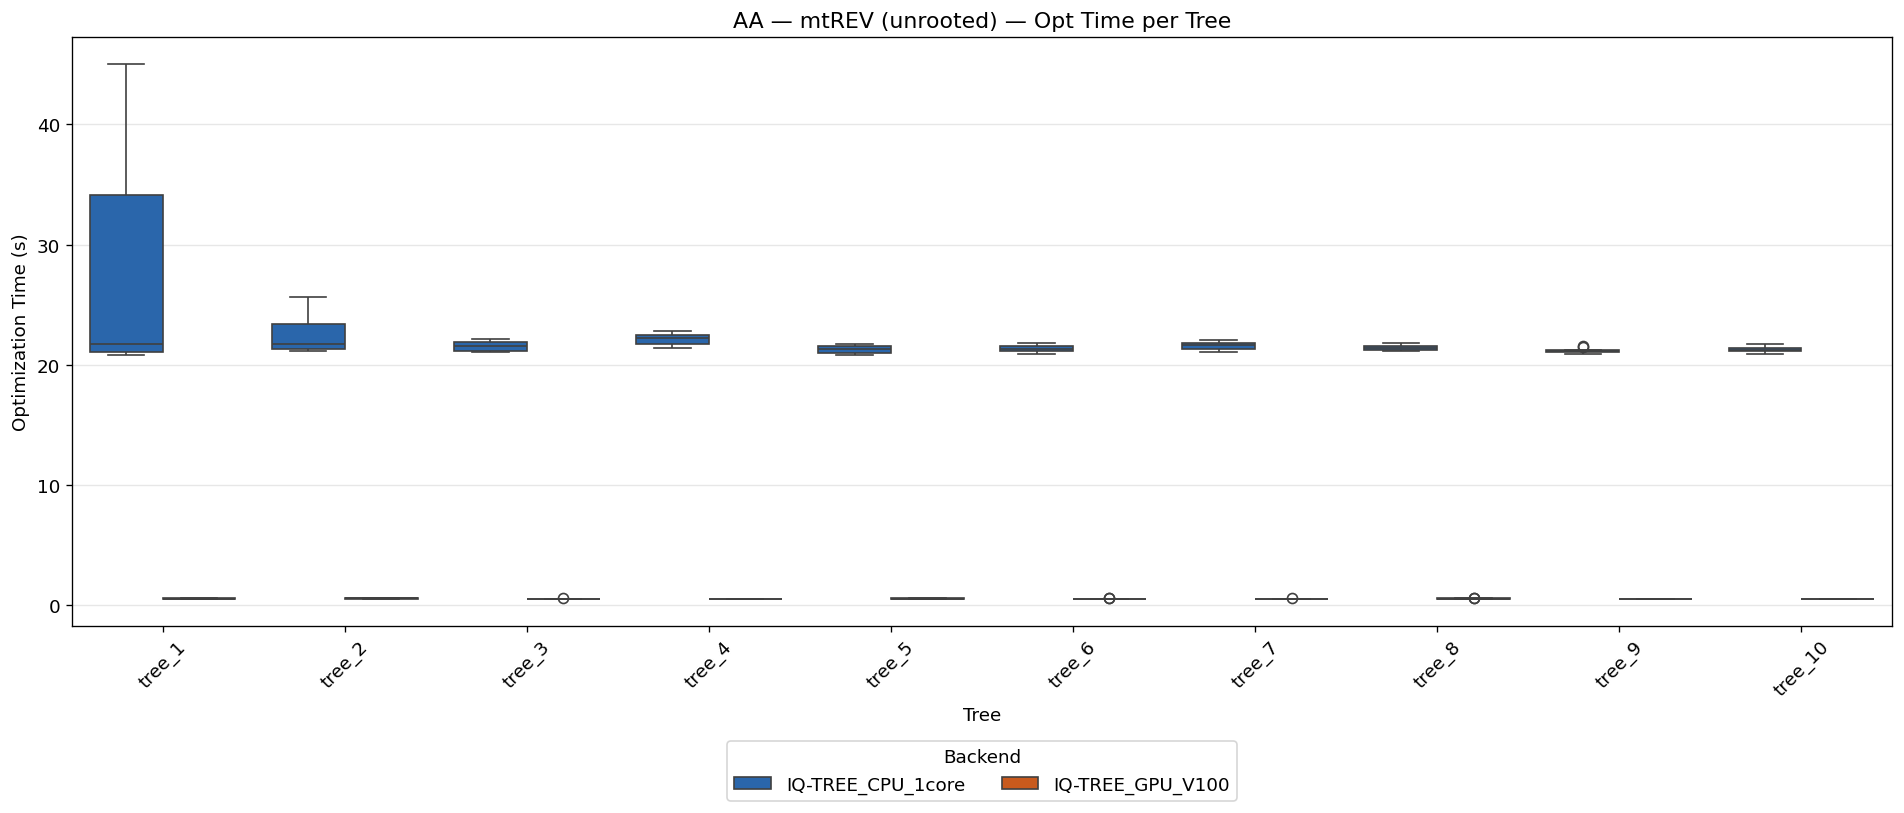

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_38260/977502804.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


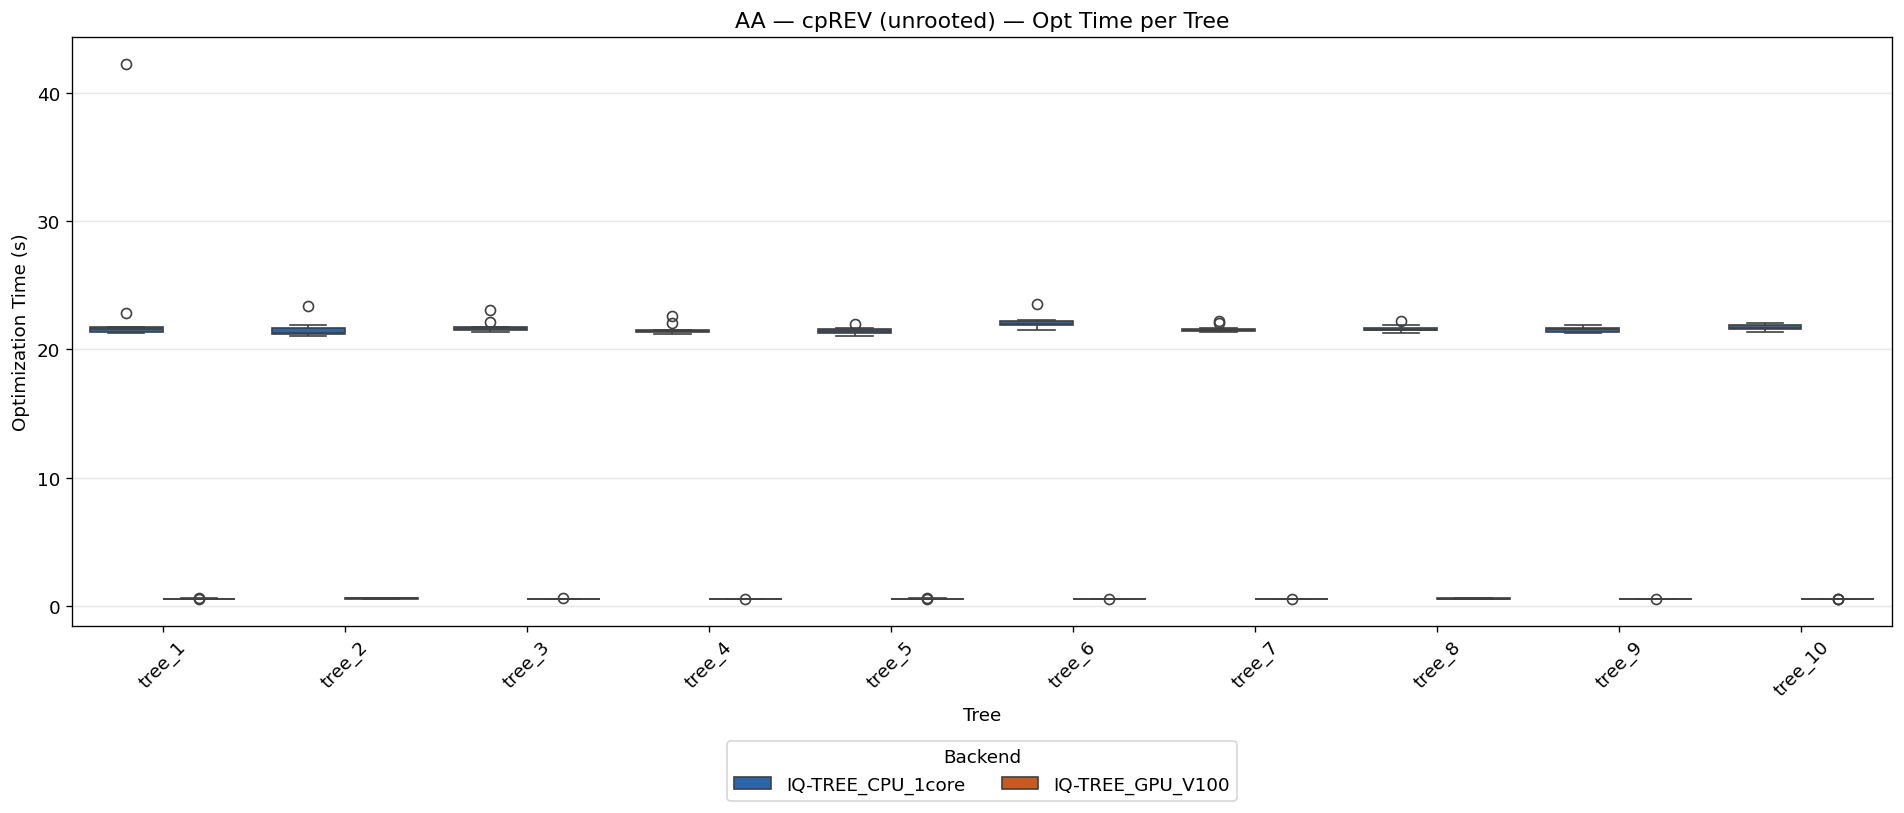

In [17]:
# AA models per-tree
for model in ['Dayhoff', 'mtREV', 'cpREV']:
    plot_per_tree_comparison(df, 'AA', model, 'unrooted',
                              path=f"{cwd}/per_tree_AA_{model}_unrooted.png")

# 9. Bar+Box Runtime Distribution per Tree

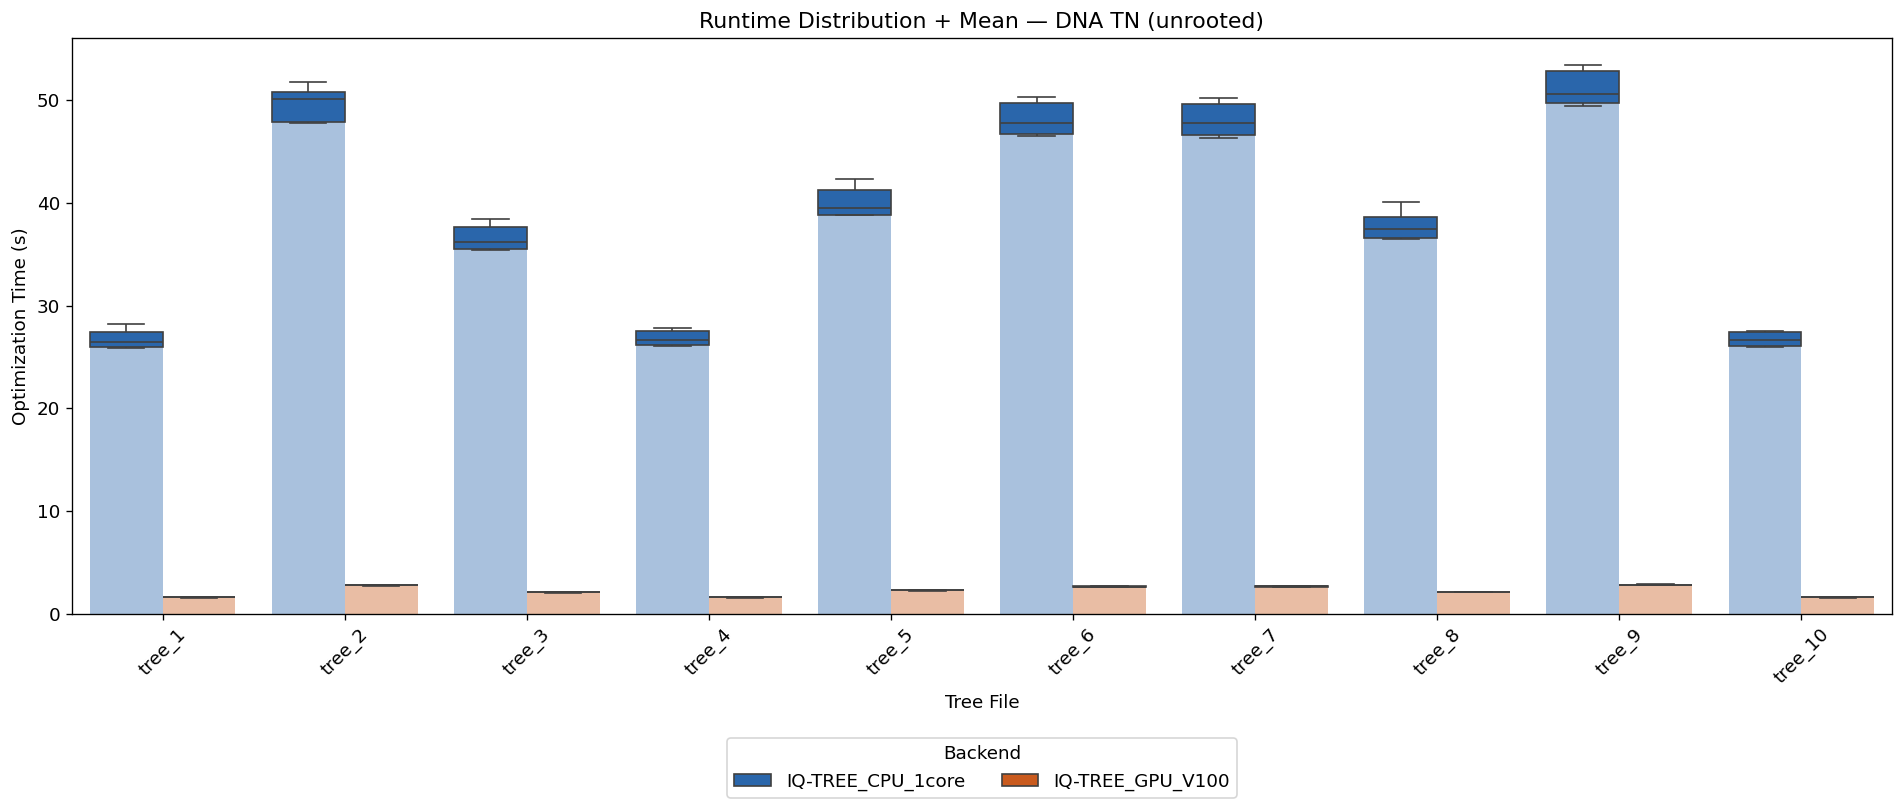

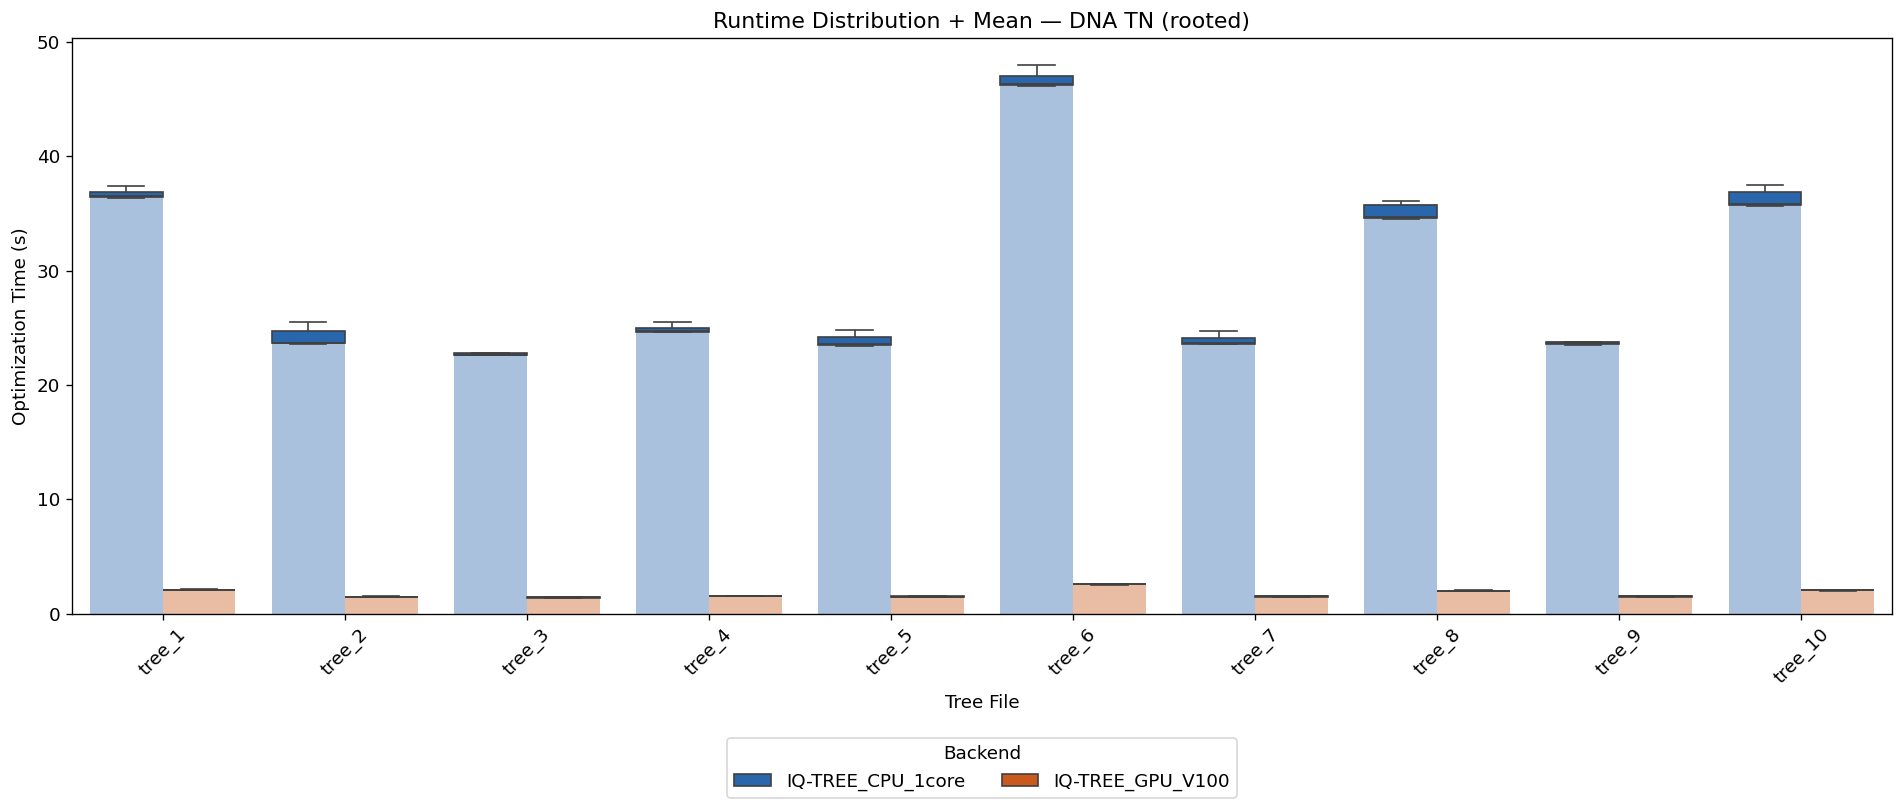

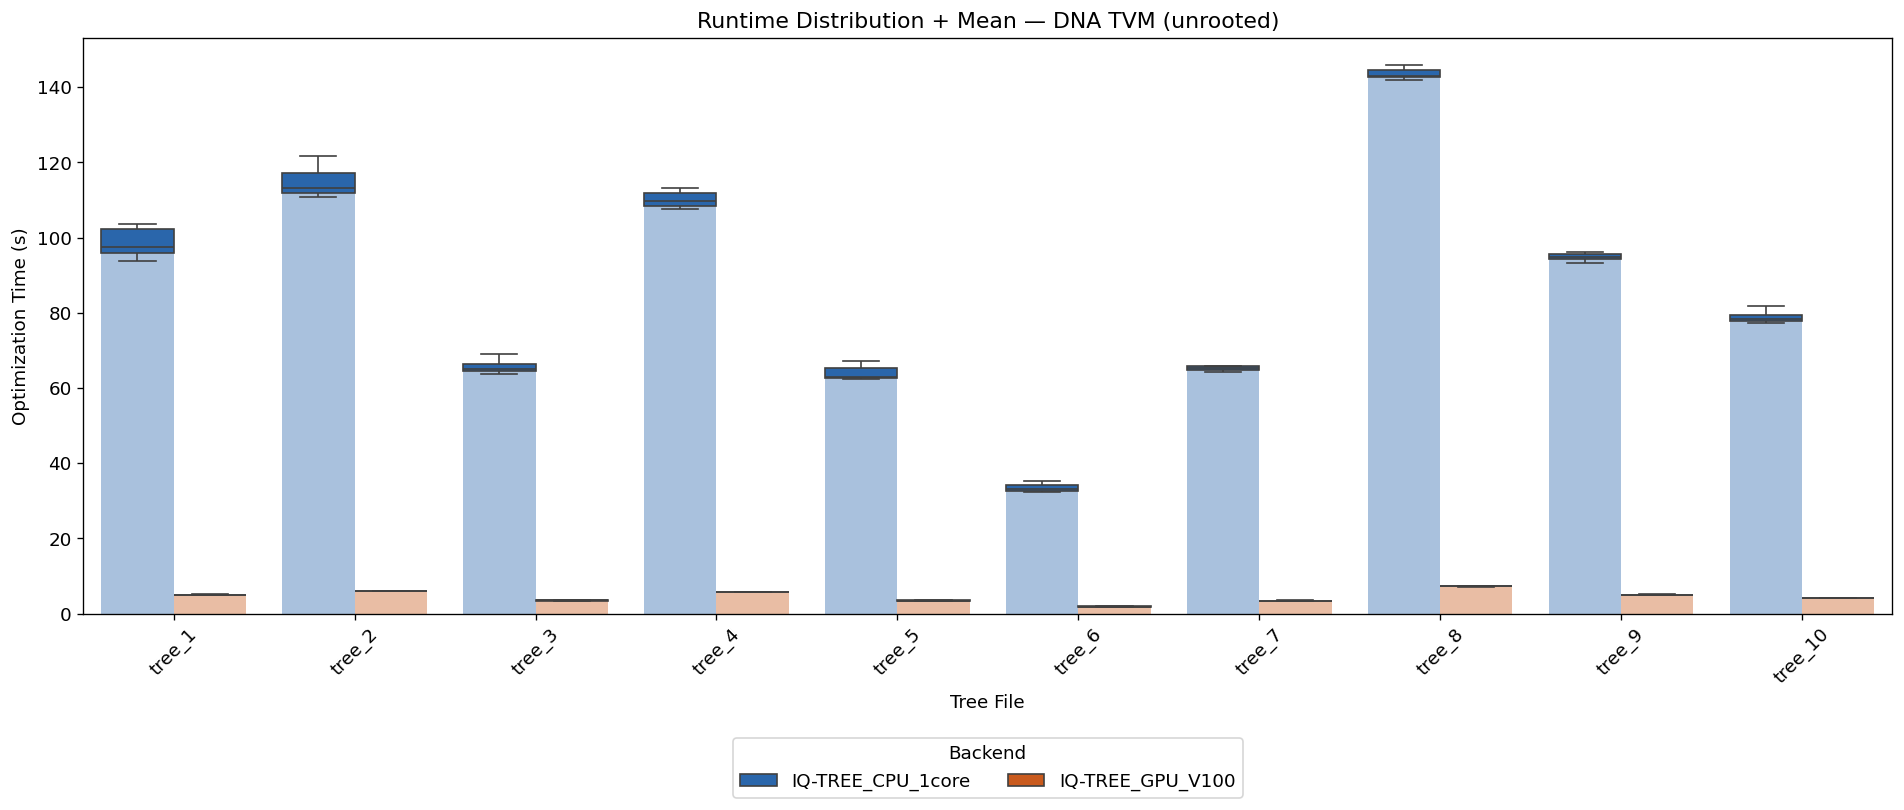

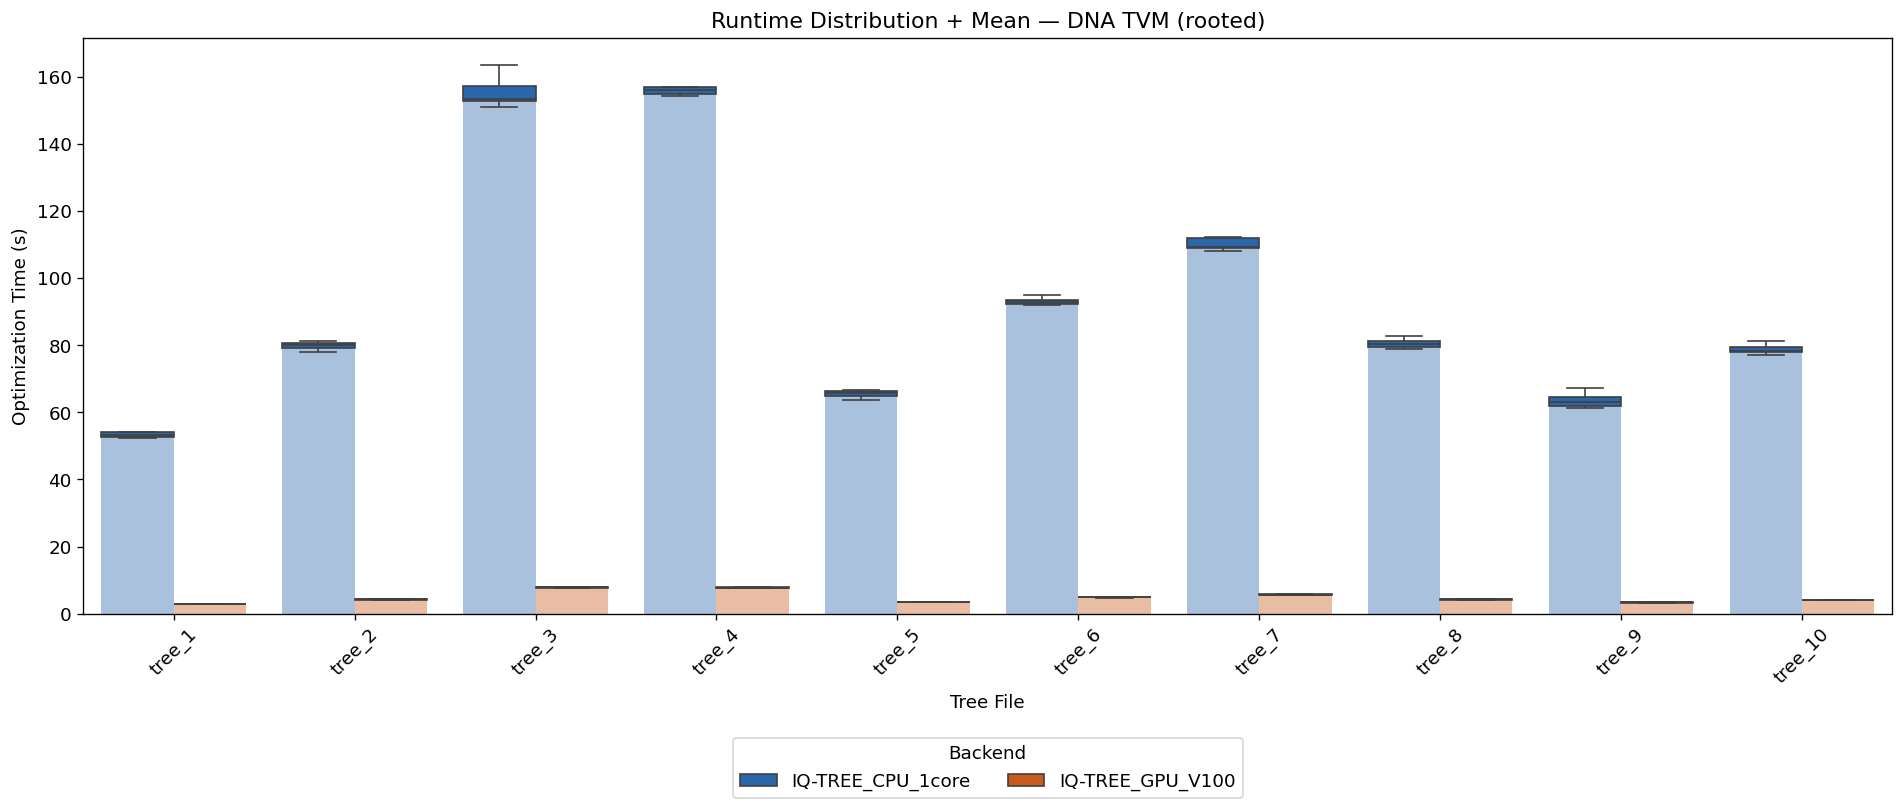

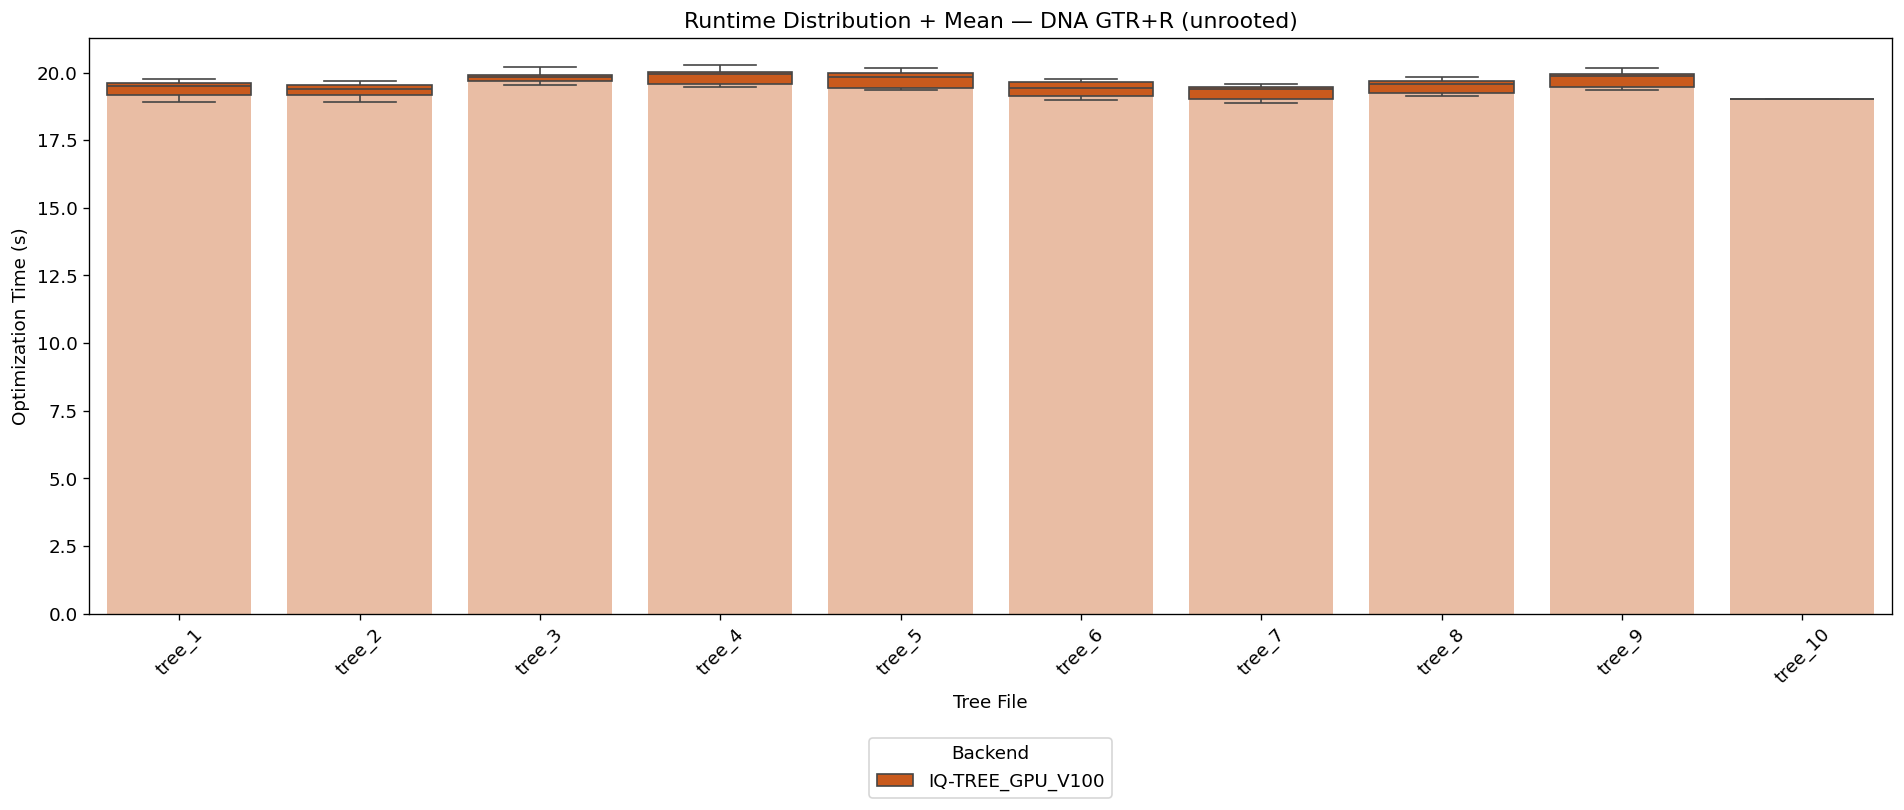

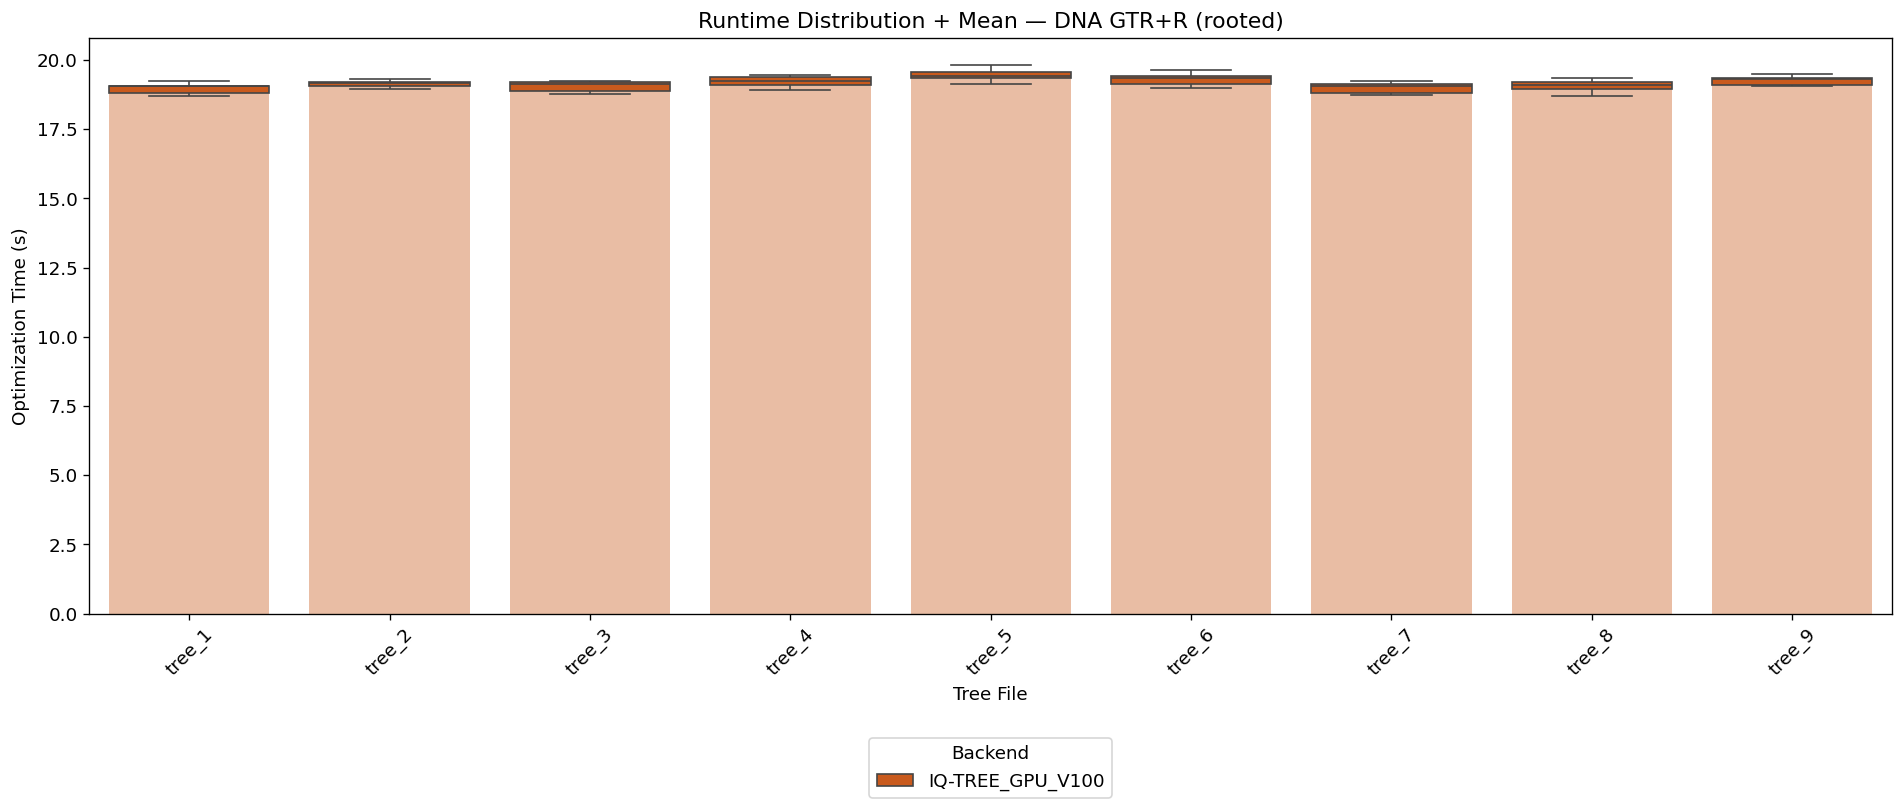

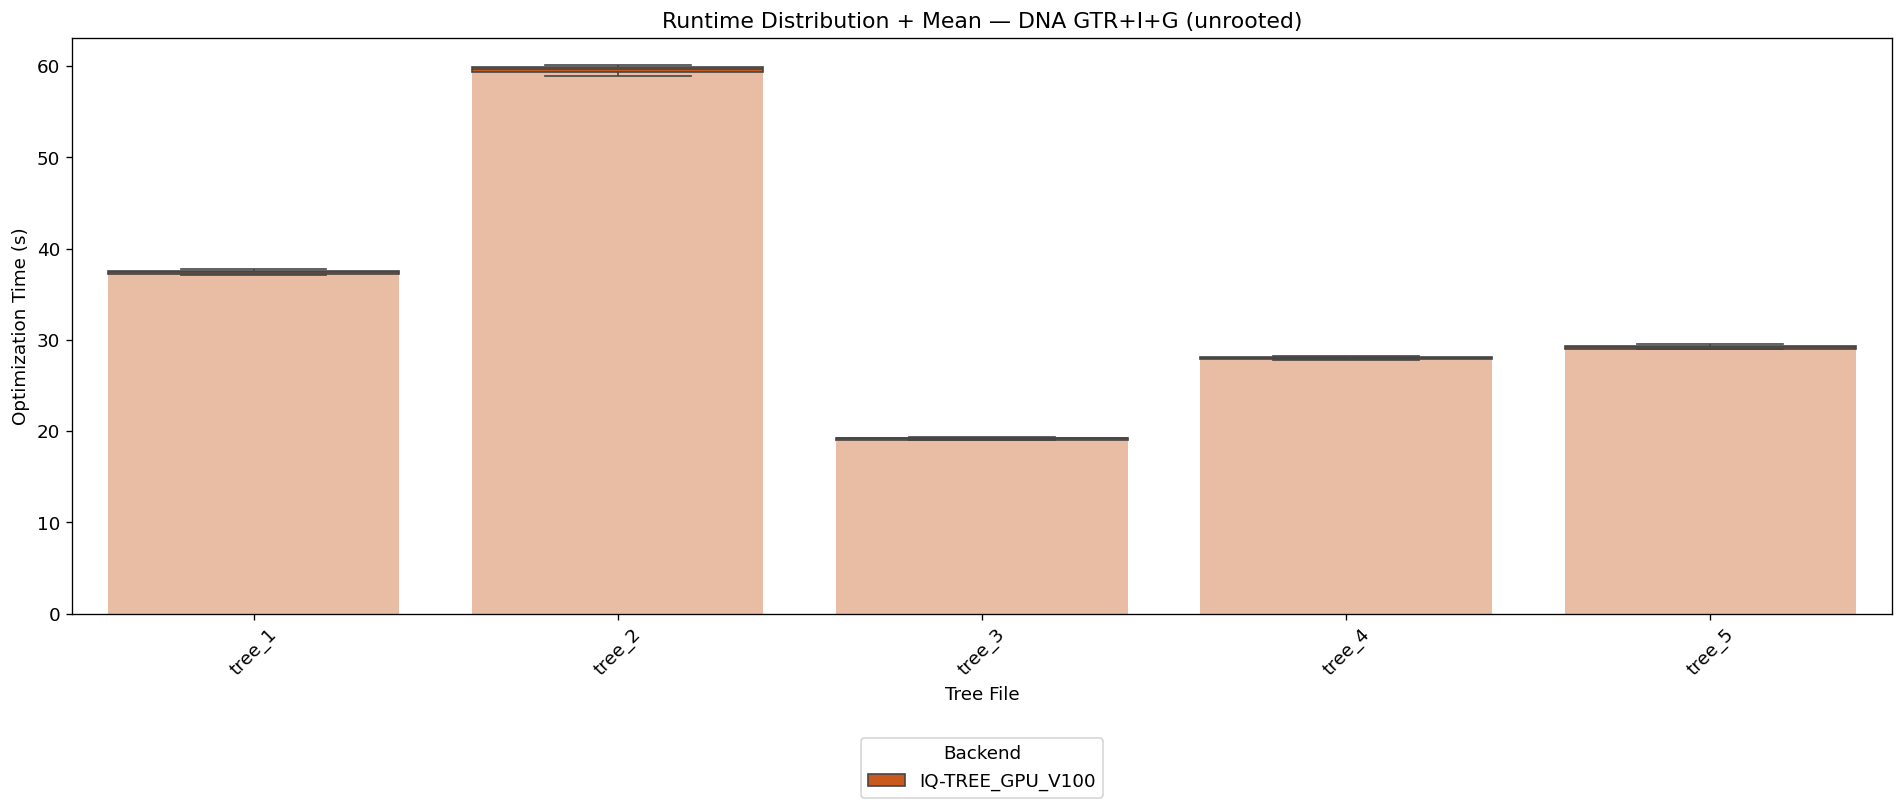

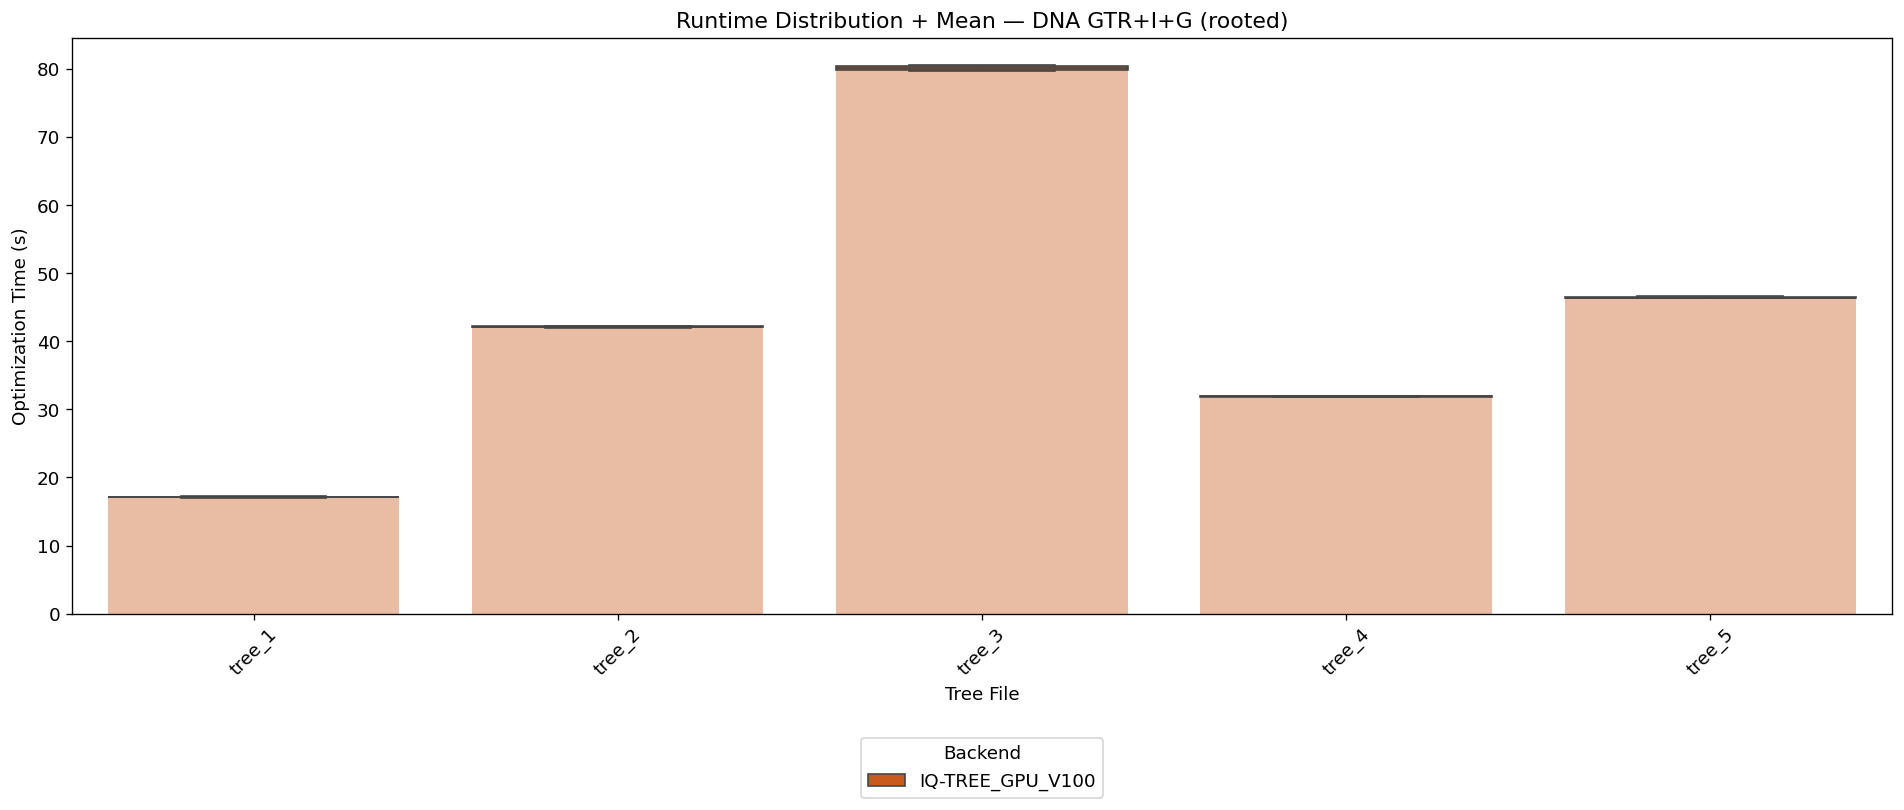

In [18]:
def plot_bar_with_box(df, data_type, model, tree_type='unrooted',
                      time_col='opt_time', figsize=(16, 7), path=""):
    """
    Boxplot (distribution) with mean bar overlay — per tree per backend.
    """
    subset = df[(df['data_type'] == data_type) &
                (df['model'] == model) &
                (df['tree_type'] == tree_type)].copy()
    if len(subset) == 0:
        print(f"No data for {data_type}/{model}/{tree_type}")
        return

    present_backends = [b for b in BACKEND_ORDER if b in subset['backend'].unique()]
    tree_order = sorted(subset['treefile'].unique(),
                        key=lambda x: int(re.search(r'\d+', x).group()))
    palette_dict = {b: BACKEND_PALETTE.get(b, '#999999') for b in present_backends}

    plt.figure(figsize=figsize)

    sns.boxplot(
        data=subset, x='treefile', y=time_col, hue='backend',
        hue_order=present_backends, order=tree_order,
        showfliers=False, linewidth=1, palette=palette_dict
    )
    sns.barplot(
        data=subset, x='treefile', y=time_col, hue='backend',
        hue_order=present_backends, order=tree_order,
        estimator='mean', errorbar=None, alpha=0.4,
        dodge=True, palette=palette_dict
    )

    plt.title(f'Runtime Distribution + Mean — {data_type} {model} ({tree_type})')
    plt.xticks(rotation=45)
    plt.ylabel('Optimization Time (s)')
    plt.xlabel('Tree File')

    handles, labels = plt.gca().get_legend_handles_labels()
    n = len(present_backends)
    plt.legend(handles[:n], labels[:n], title='Backend',
               bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=n)

    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

# DNA models
for model in ['TN', 'TVM', 'GTR+R', 'GTR+I+G']:
    for tt in ['unrooted', 'rooted']:
        plot_bar_with_box(df, 'DNA', model, tt,
                          path=f"{cwd}/barbox_DNA_{model.replace('+', '_')}_{tt}.png")

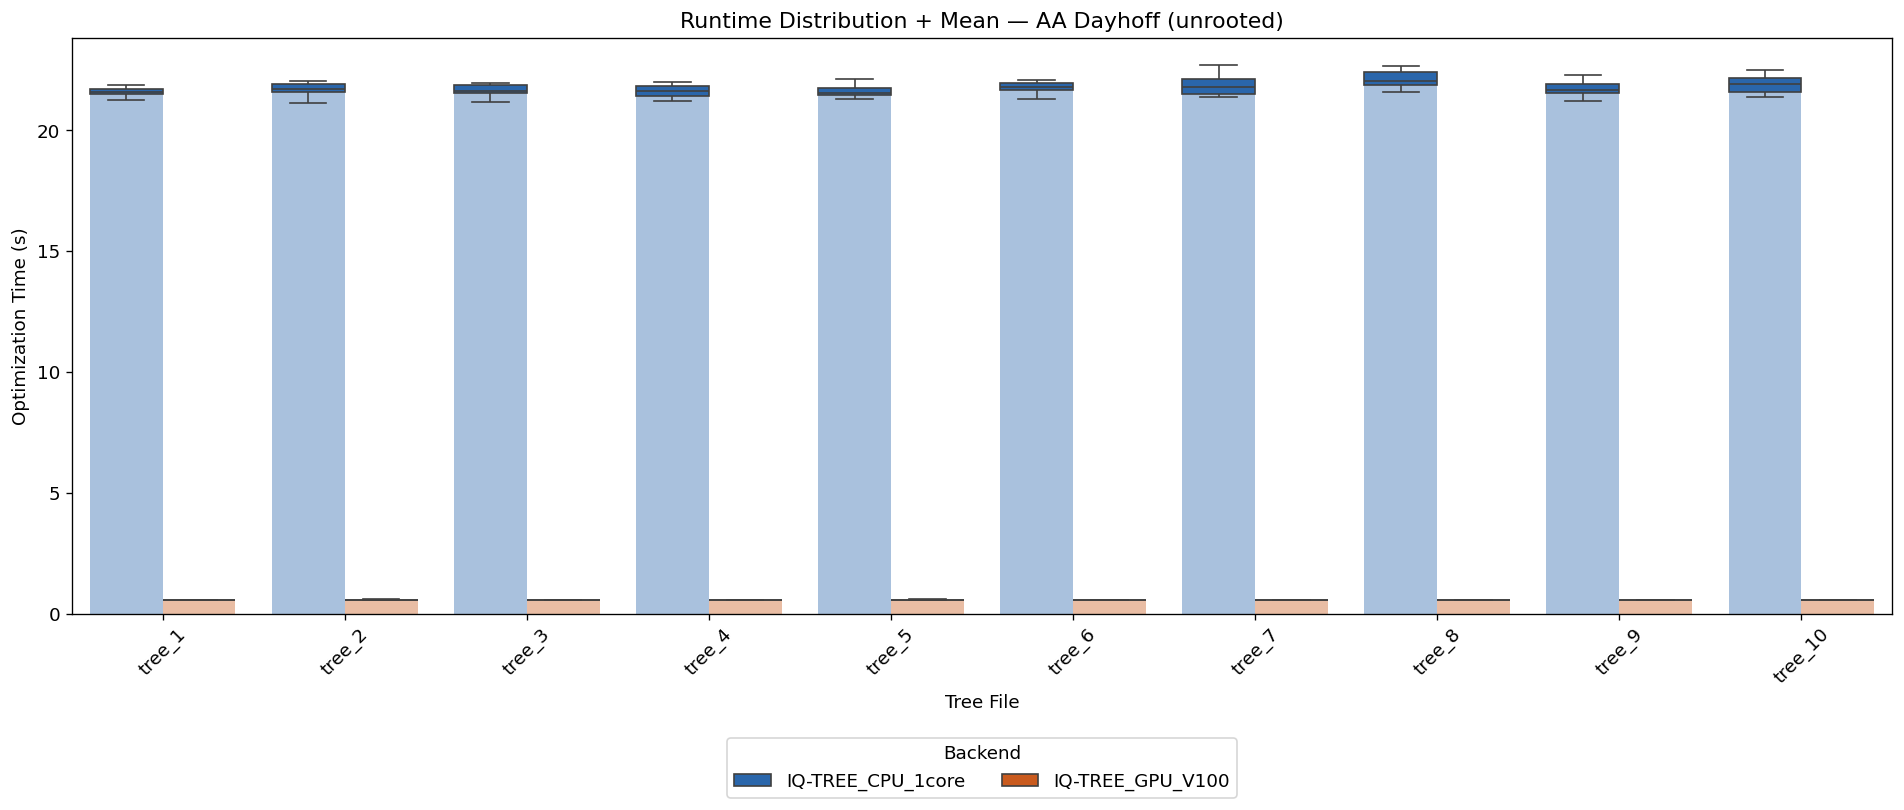

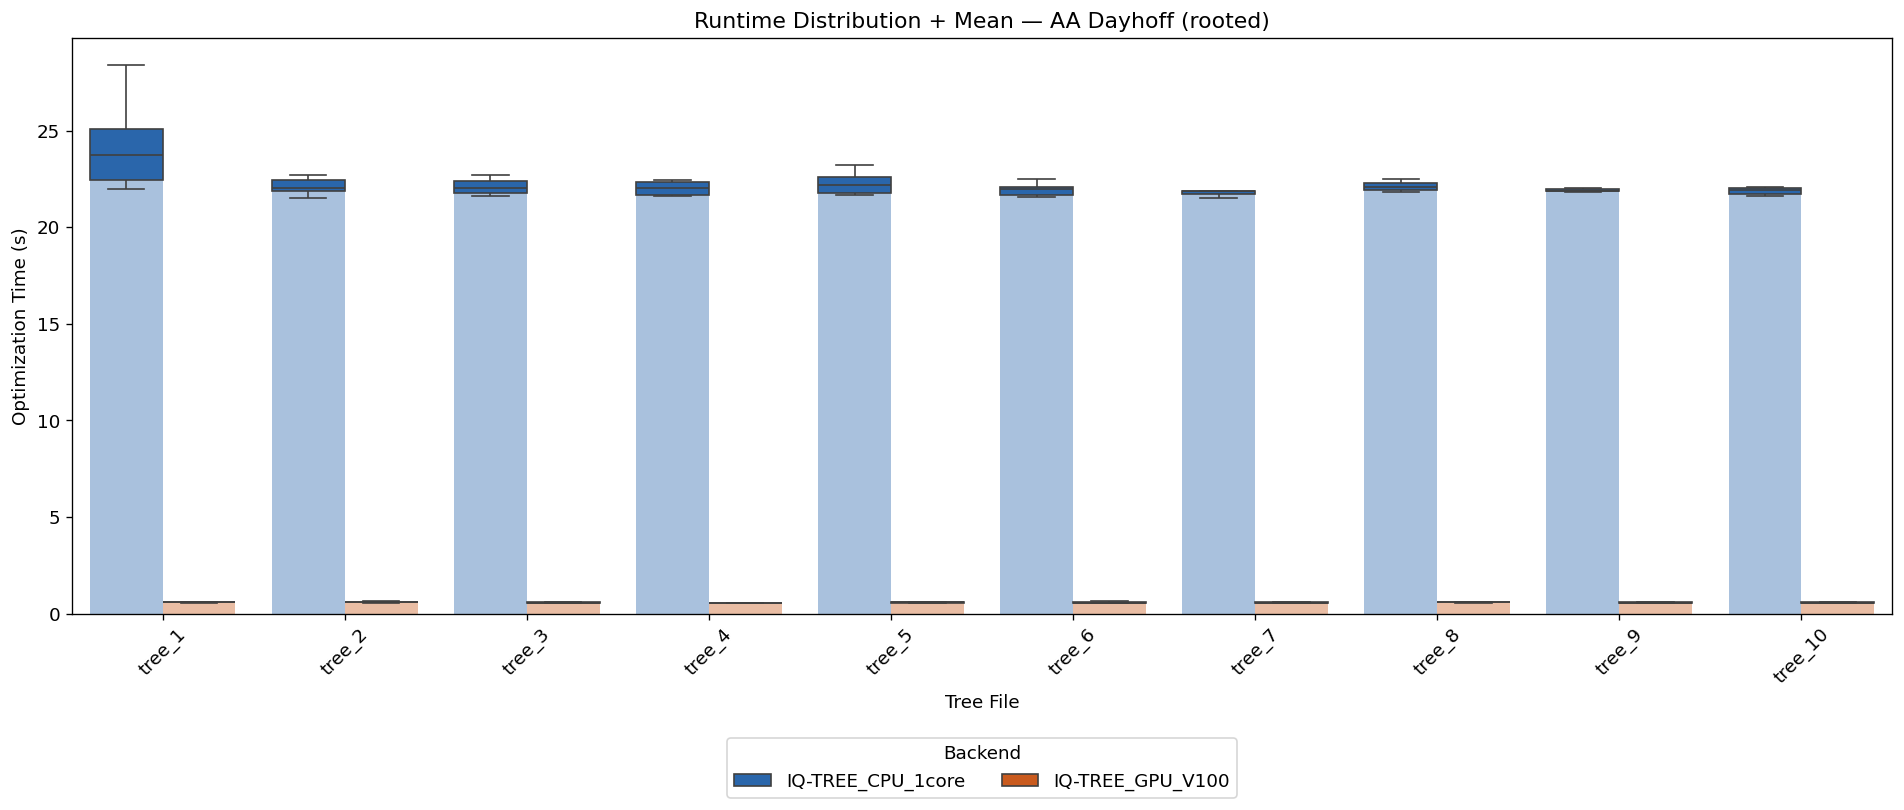

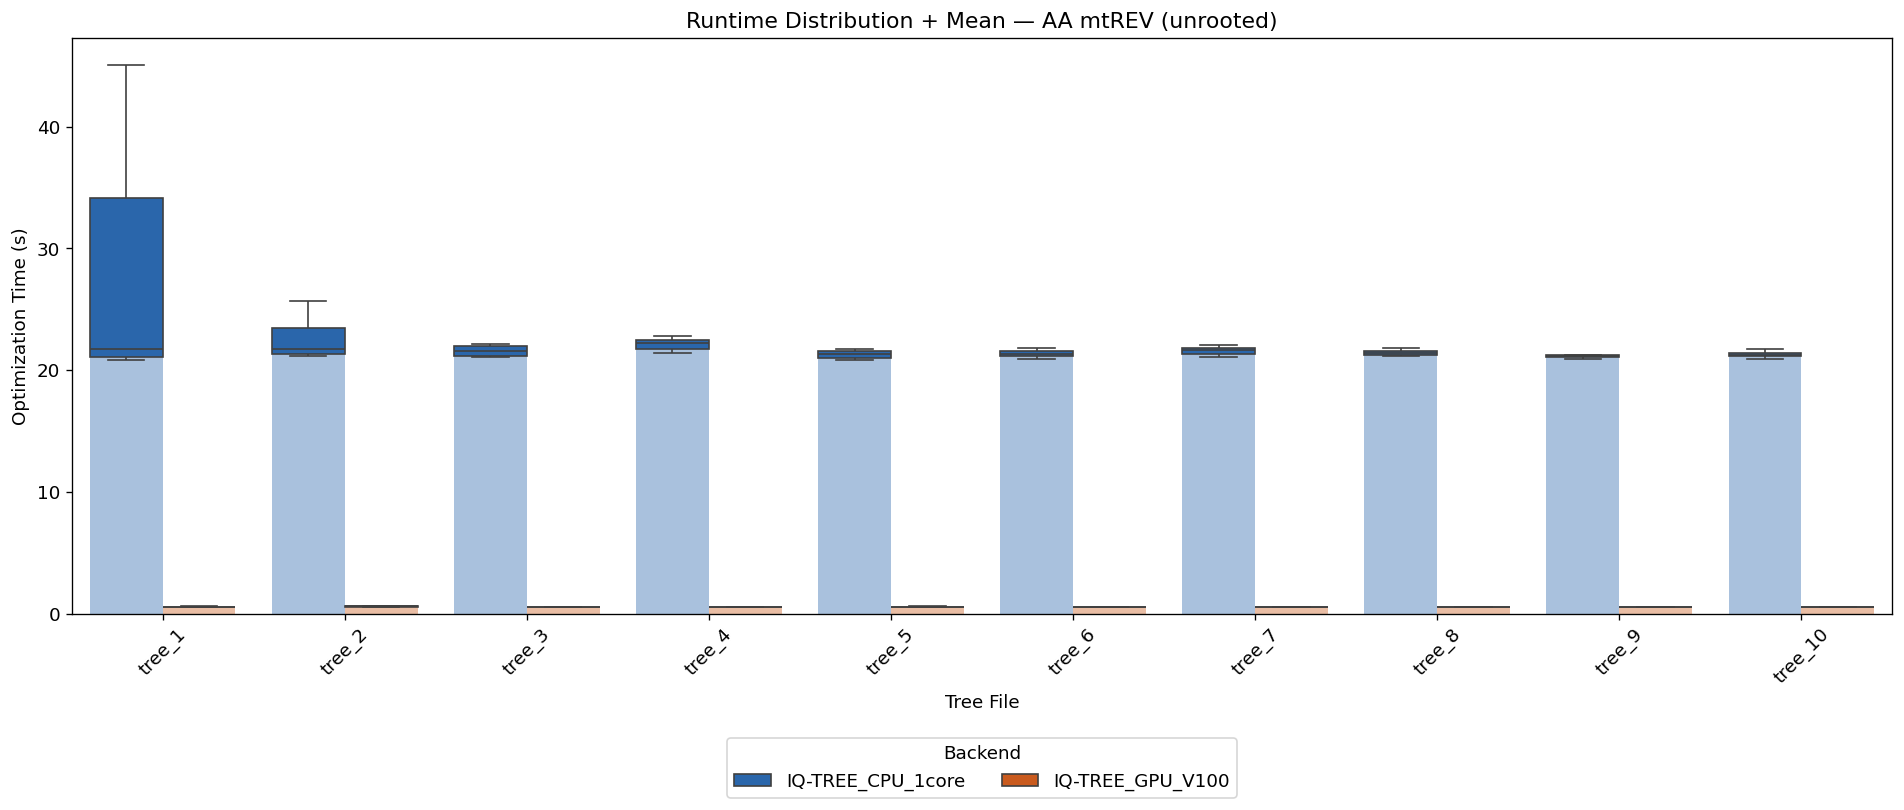

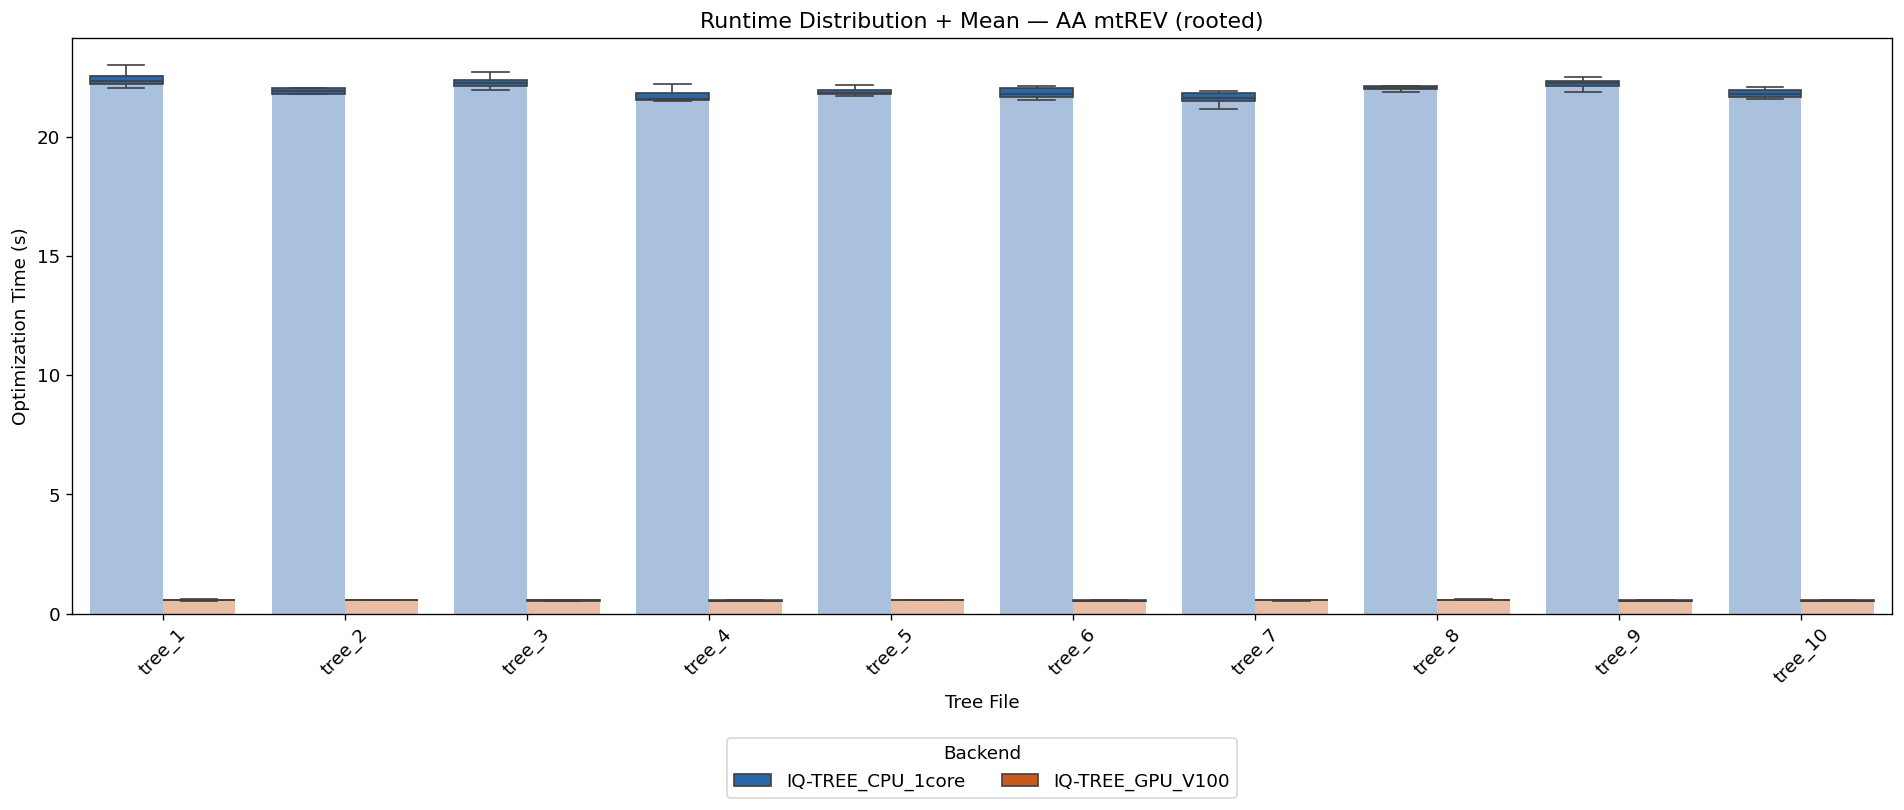

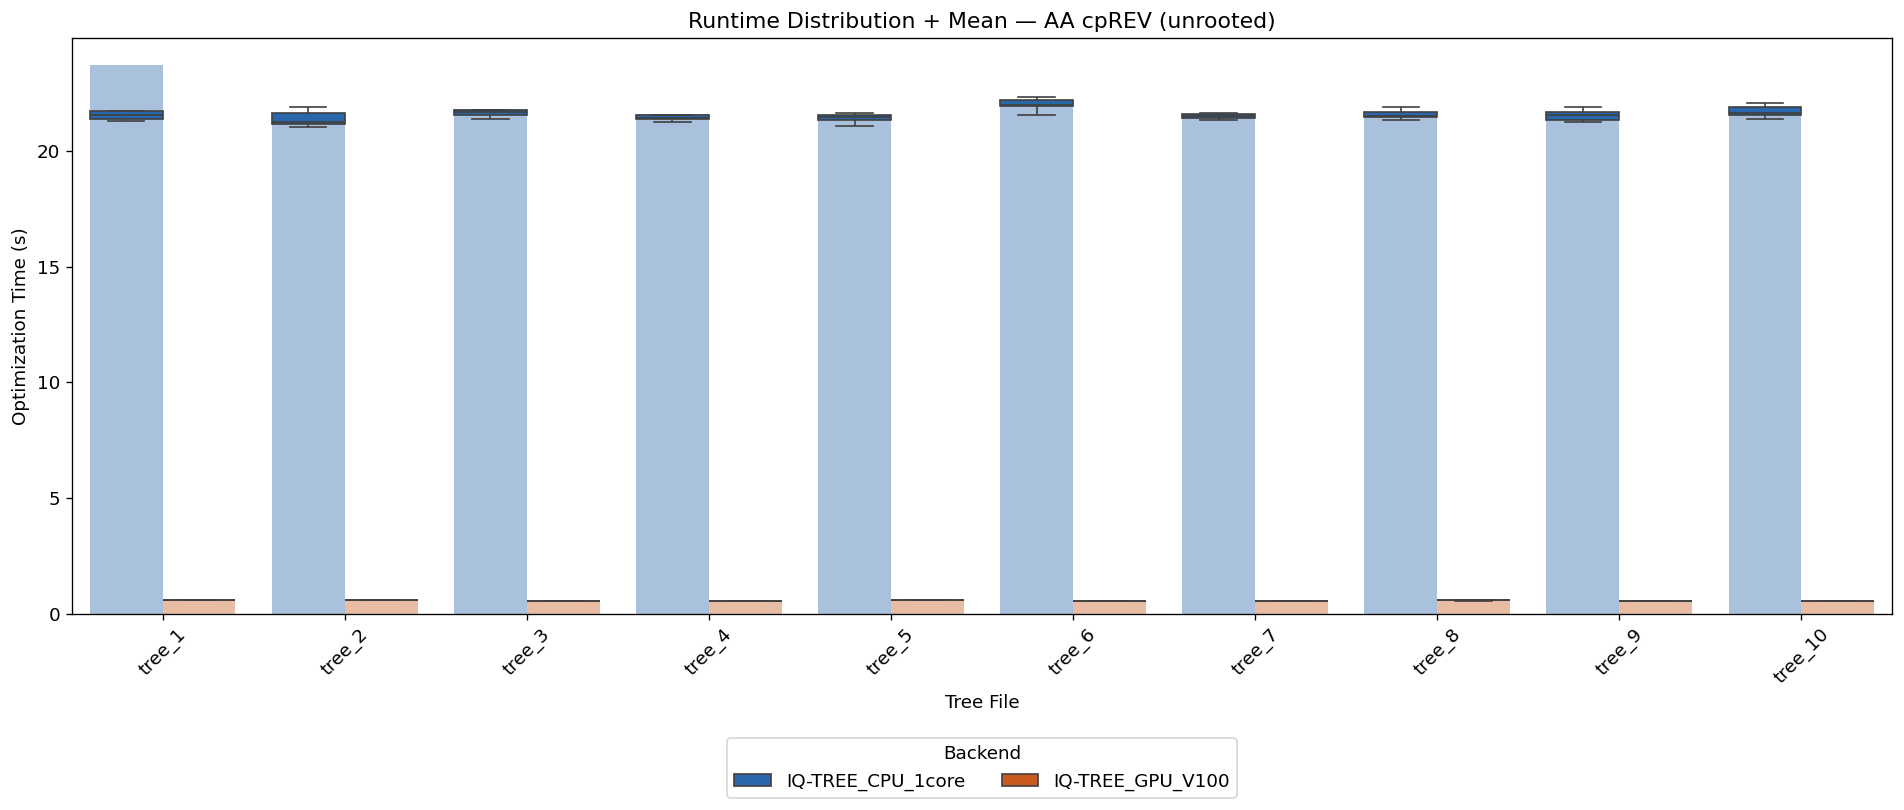

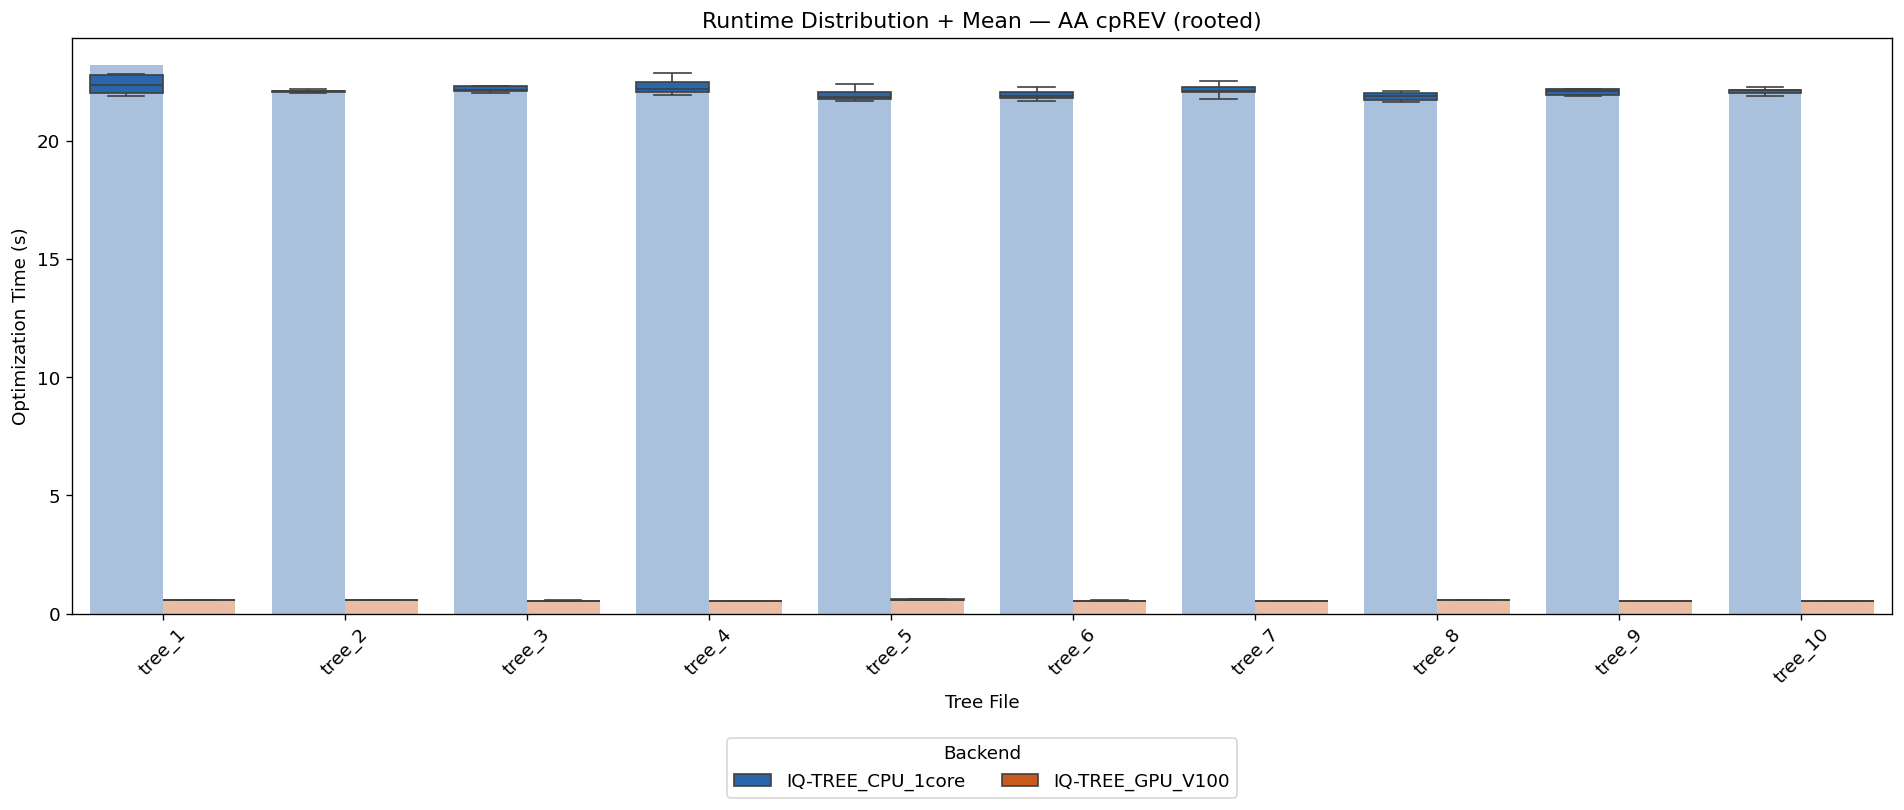

In [19]:
# AA models
for model in ['Dayhoff', 'mtREV', 'cpREV']:
    for tt in ['unrooted', 'rooted']:
        plot_bar_with_box(df, 'AA', model, tt,
                          path=f"{cwd}/barbox_AA_{model}_{tt}.png")

# 10. Combined Overview Plots

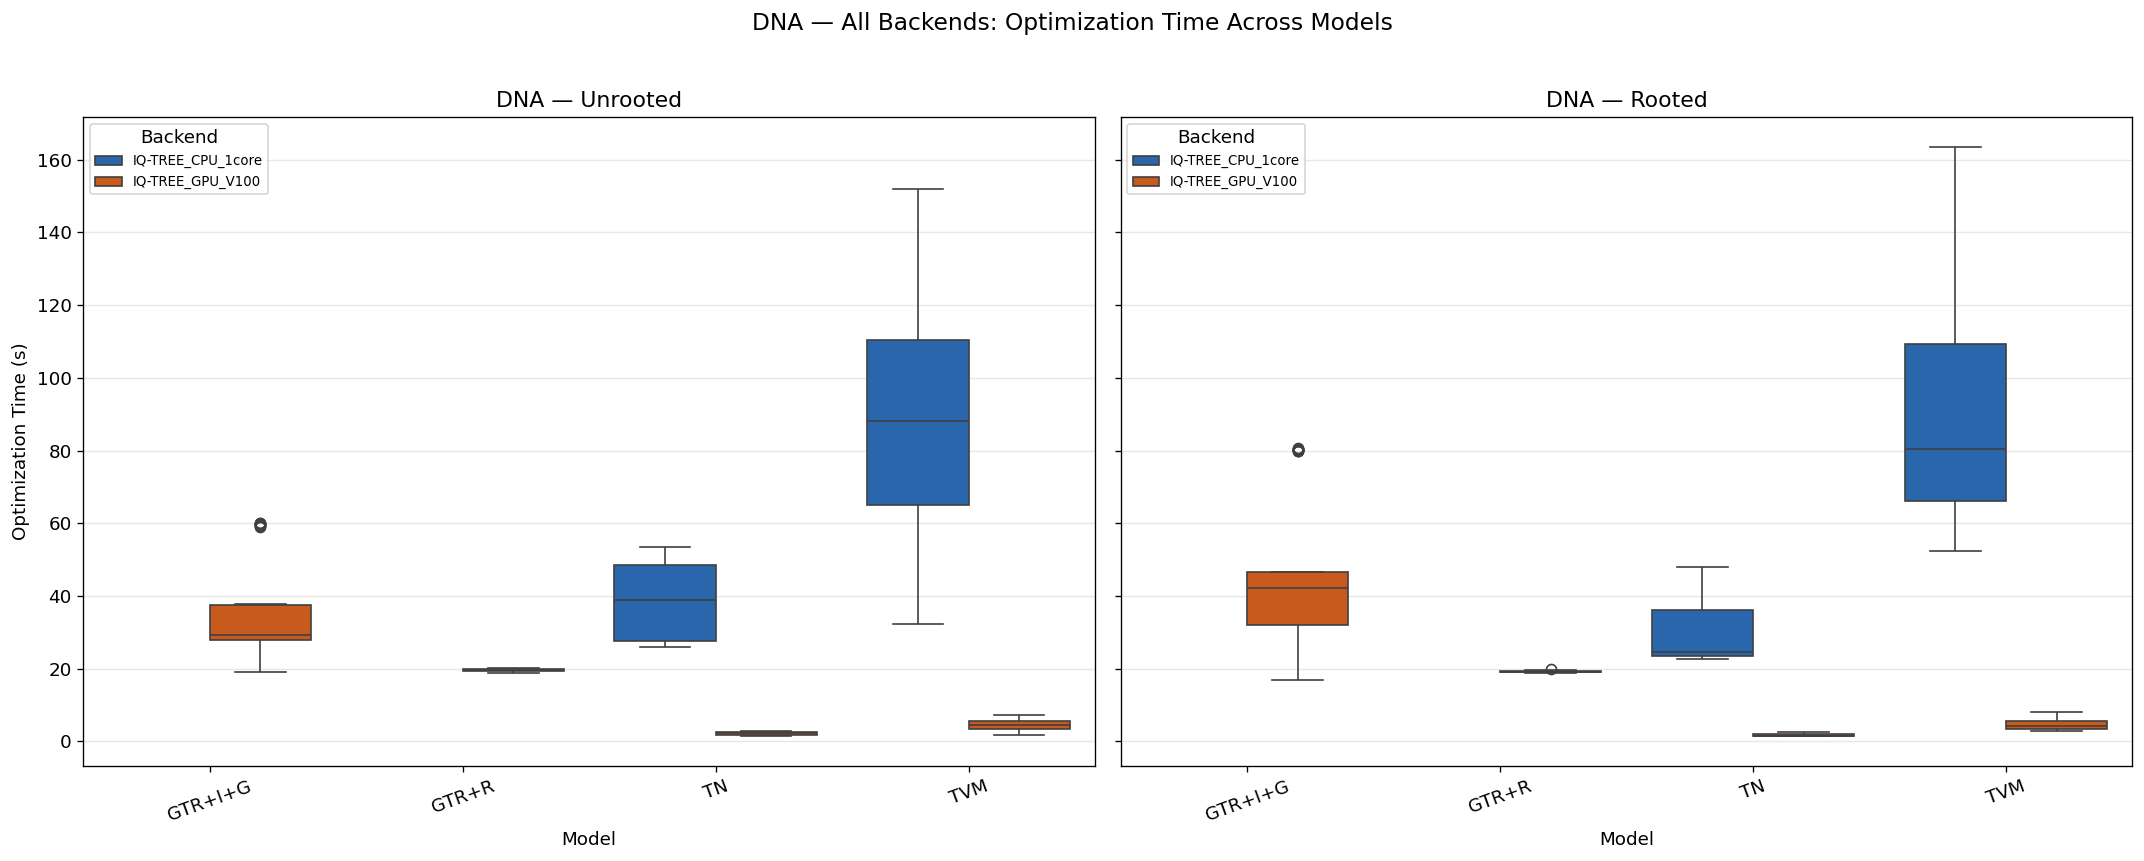

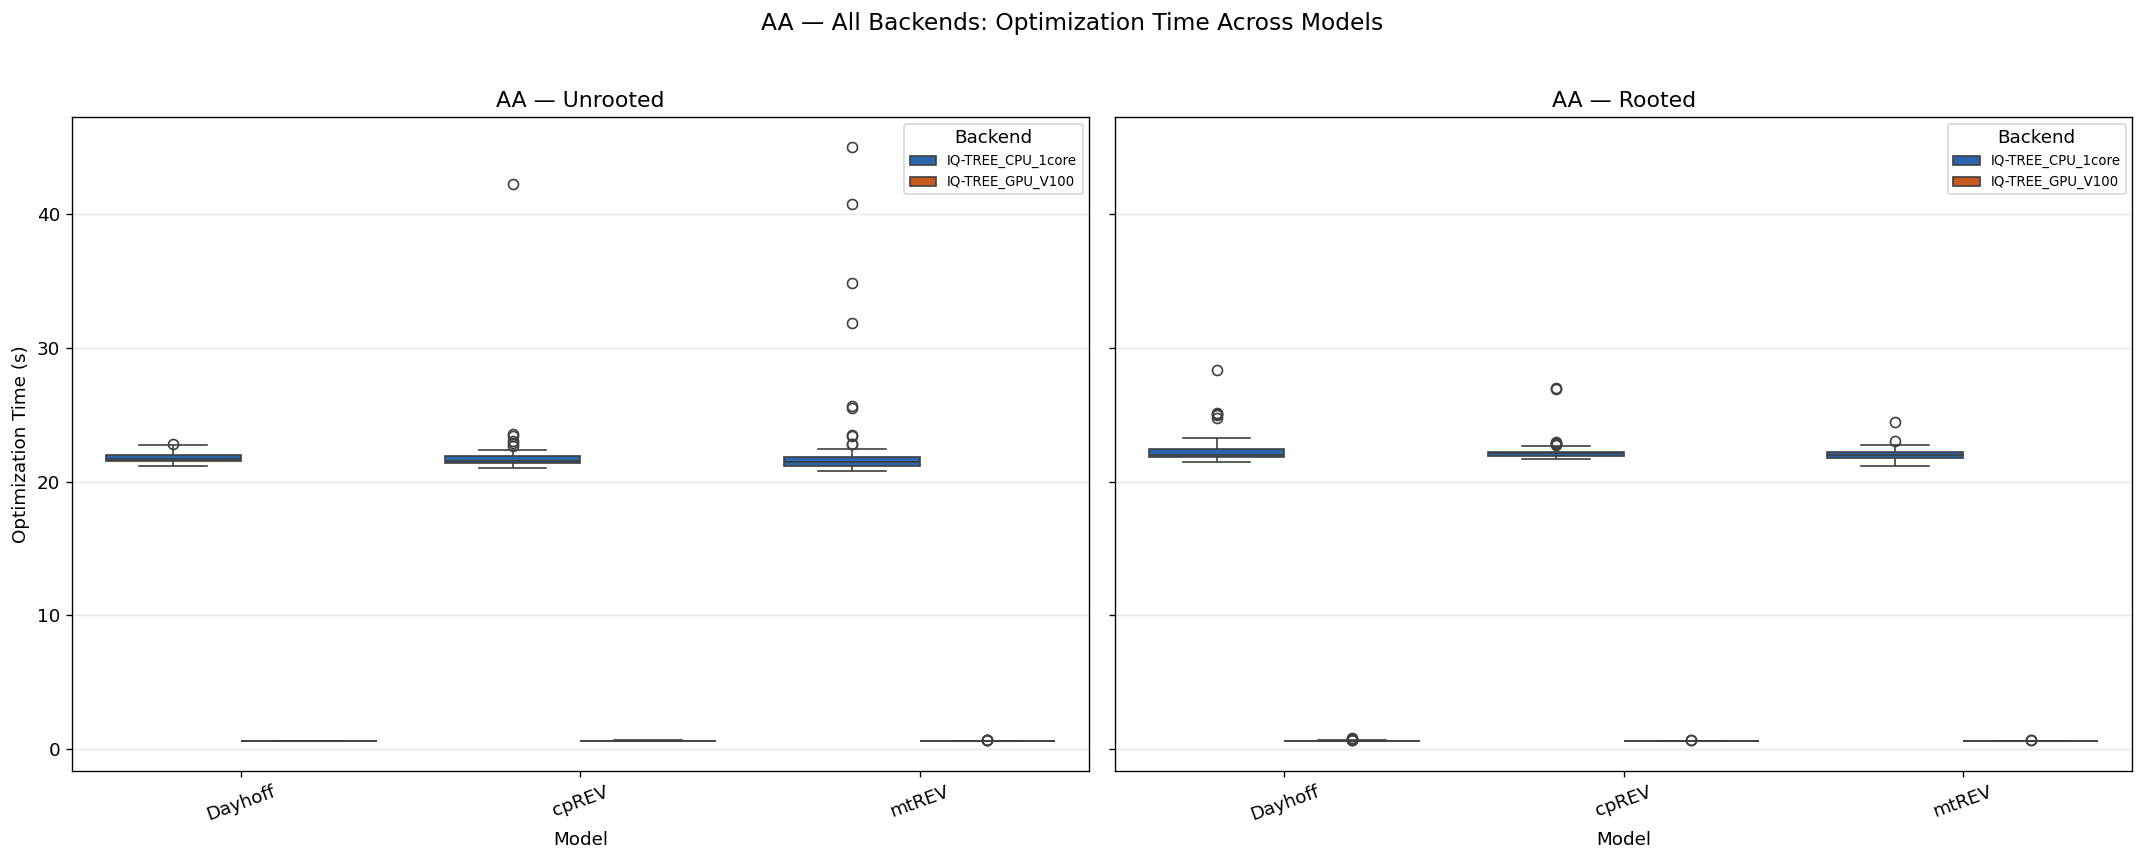

In [20]:
def plot_combined_overview(df, data_type, time_col='opt_time', figsize=(18, 7), path=""):
    """Side-by-side: unrooted and rooted, all models, all backends."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True)

    for ax, tt, title in [(ax1, 'unrooted', 'Unrooted'), (ax2, 'rooted', 'Rooted')]:
        subset = df[(df['data_type'] == data_type) & (df['tree_type'] == tt)]
        if len(subset) == 0:
            ax.set_title(f'{data_type} — {title} (no data)')
            continue
        present_backends = [b for b in BACKEND_ORDER if b in subset['backend'].unique()]
        sns.boxplot(data=subset, x='model', y=time_col, hue='backend',
                    hue_order=present_backends,
                    palette=BACKEND_PALETTE, ax=ax)
        ax.set_title(f'{data_type} — {title}')
        ax.set_xlabel('Model')
        ax.set_ylabel('Optimization Time (s)' if ax == ax1 else '')
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend(title='Backend', fontsize=8)
        ax.tick_params(axis='x', rotation=20)

    plt.suptitle(f'{data_type} — All Backends: Optimization Time Across Models', fontsize=14, y=1.02)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

plot_combined_overview(df, 'DNA', path=f"{cwd}/combined_overview_DNA.png")
plot_combined_overview(df, 'AA',  path=f"{cwd}/combined_overview_AA.png")

# 11. Speedup Heatmap — Detailed (opt_time per tree)

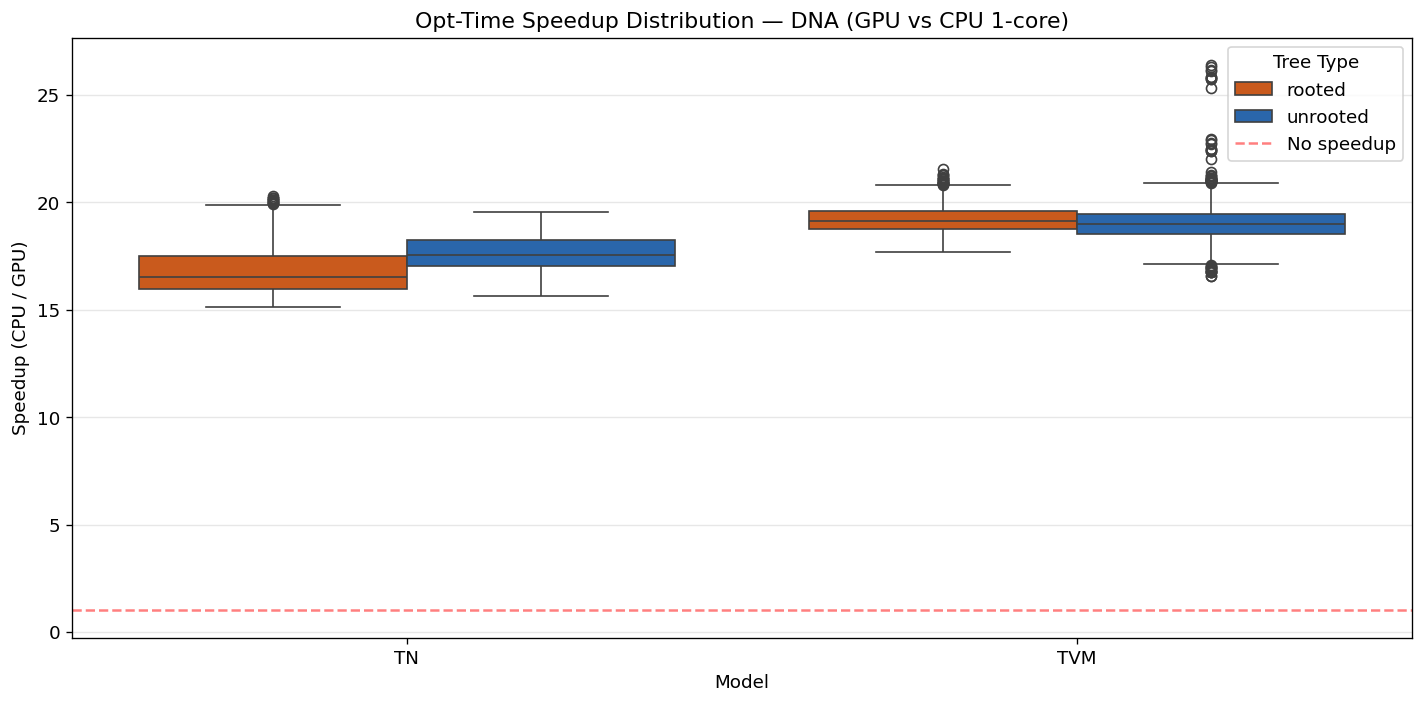

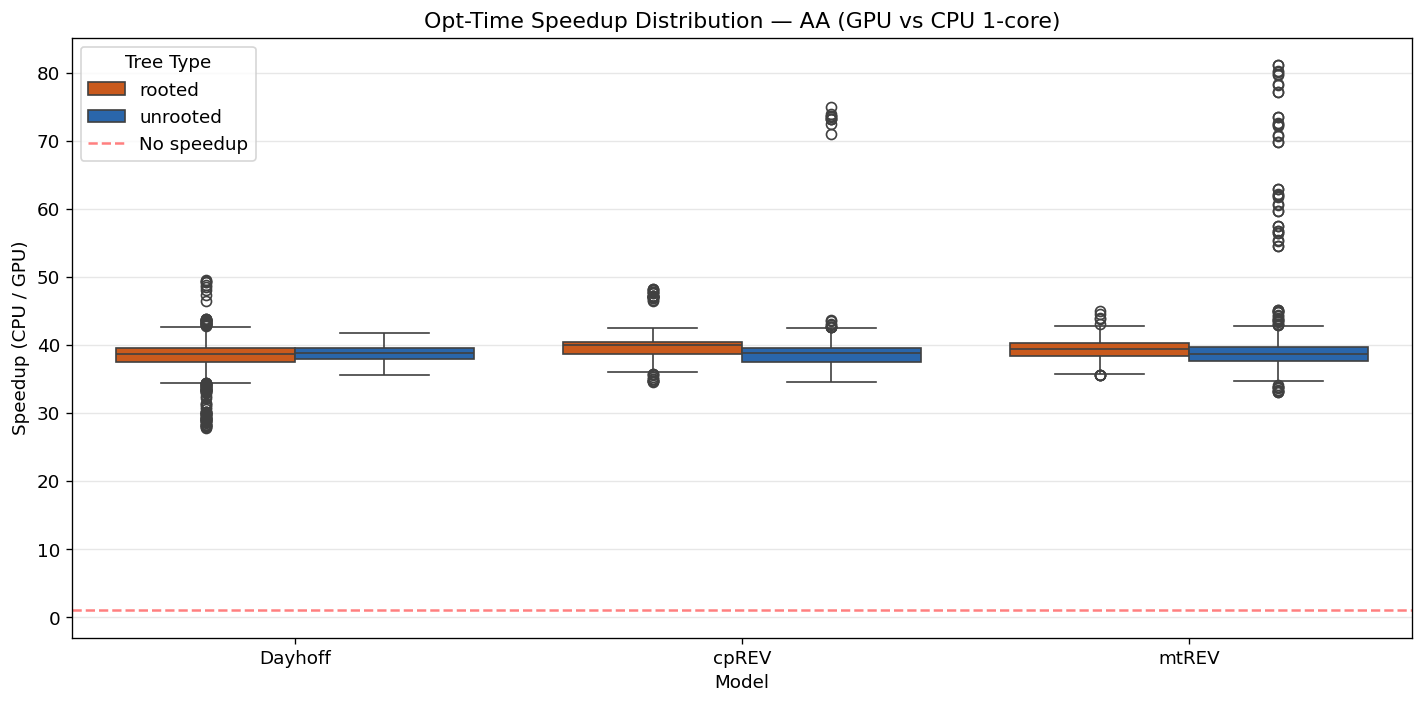

In [21]:
def plot_opt_speedup_boxplot(speedup_df, data_type, figsize=(12, 6), path=""):
    """Boxplot of opt-time speedup per model, split by tree type."""
    subset = speedup_df[speedup_df['data_type'] == data_type]
    if len(subset) == 0:
        print(f"No speedup data for {data_type}")
        return

    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=subset, x='model', y='speedup_opt', hue='tree_type',
                palette={'rooted': '#E65100', 'unrooted': '#1565C0'}, ax=ax)

    ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='No speedup')
    ax.set_title(f'Opt-Time Speedup Distribution — {data_type} (GPU vs CPU 1-core)')
    ax.set_xlabel('Model')
    ax.set_ylabel('Speedup (CPU / GPU)')
    ax.legend(title='Tree Type')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

plot_opt_speedup_boxplot(speedup_1core, 'DNA', path=f"{cwd}/opt_speedup_box_DNA.png")
plot_opt_speedup_boxplot(speedup_1core, 'AA',  path=f"{cwd}/opt_speedup_box_AA.png")

In [22]:
# Detailed per-model per-tree_type speedup table
print("=" * 90)
print("OPT-TIME SPEEDUP: GPU vs CPU 1-core (per model, per tree_type)")
print("=" * 90)
display(speedup_1core.groupby(['data_type', 'tree_type', 'model'])['speedup_opt'].agg(
    ['mean', 'median', 'min', 'max', 'std']).round(2))

OPT-TIME SPEEDUP: GPU vs CPU 1-core (per model, per tree_type)


mean  median    min    max   std
data_type tree_type model                                     
AA        rooted    Dayhoff  38.29   38.67  27.76  49.54  2.69
                    cpREV    39.69   39.93  34.61  48.28  1.72
                    mtREV    39.31   39.42  35.55  45.01  1.33
          unrooted  Dayhoff  38.78   38.89  35.64  41.73  1.14
                    cpREV    38.88   38.79  34.62  74.95  3.75
                    mtREV    39.75   38.67  33.07  81.16  6.12
DNA       rooted    TN       16.77   16.51  15.11  20.32  1.01
                    TVM      19.23   19.15  17.70  21.55  0.64
          unrooted  TN       17.62   17.56  15.64  19.56  0.86
                    TVM      19.10   19.00  16.59  26.41  1.13

# 12. Likelihood Verification

Verify that GPU and CPU backends produce numerically identical log-likelihood values.

In [23]:
# Check: within each backend, are all runs consistent (std = 0)?
print("=== Likelihood Std-Dev within each (backend, model, tree) across runs ===")
ll_std = df.groupby(['data_type', 'tree_type', 'model', 'treefile', 'backend'])['likelihood'].std()
ll_std_nonzero = ll_std[ll_std > 0]
if len(ll_std_nonzero) == 0:
    print("All backends are perfectly deterministic — std=0 across all runs.")
else:
    print(f"WARNING: {len(ll_std_nonzero)} groups have non-zero std:")
    display(ll_std_nonzero.head(20))

=== Likelihood Std-Dev within each (backend, model, tree) across runs ===
All backends are perfectly deterministic — std=0 across all runs.


In [24]:
# Cross-backend comparison: mean LL per (data_type, tree_type, model, treefile, backend)
ll_means = df.groupby(['data_type', 'tree_type', 'model', 'treefile', 'backend'])['likelihood'].mean().unstack('backend')
present_cols = [b for b in BACKEND_ORDER if b in ll_means.columns]
ll_means = ll_means[present_cols]

print("=== Mean Log-Likelihood per Configuration (sample) ===")
display(ll_means.head(20))

=== Mean Log-Likelihood per Configuration (sample) ===


backend                               IQ-TREE_CPU_1core  IQ-TREE_GPU_V100
data_type tree_type model   treefile                                     
AA        rooted    Dayhoff tree_1        -9.290282e+07     -9.290282e+07
                            tree_10       -8.073522e+07     -8.073522e+07
                            tree_2        -8.839765e+07     -8.839765e+07
                            tree_3        -8.727544e+07     -8.727544e+07
                            tree_4        -9.298115e+07     -9.298115e+07
                            tree_5        -8.531287e+07     -8.531287e+07
                            tree_6        -8.748886e+07     -8.748886e+07
                            tree_7        -8.172768e+07     -8.172768e+07
                            tree_8        -8.693951e+07     -8.693951e+07
                            tree_9        -8.189543e+07     -8.189543e+07
                    cpREV   tree_1        -8.955274e+07     -8.955274e+07
                            tree_10       -9.112120e+07     -9.112120e+07
                            tree_2        -9.154721e+07     -9.154721e+07
                            tree_3        -9.226600e+07     -9.226600e+07
                            tree_4        -8.944506e+07     -8.944506e+07
                            tree_5        -8.982902e+07     -8.982902e+07
                            tree_6        -8.346217e+07     -8.346217e+07
                            tree_7        -8.887324e+07     -8.887324e+07
                            tree_8        -8.443905e+07     -8.443905e+07
                            tree_9        -8.789185e+07     -8.789185e+07

In [25]:
# Pairwise LL differences
print("=== Pairwise Likelihood Differences (max absolute diff) ===")
diff_results = []
for i, b1 in enumerate(present_cols):
    for b2 in present_cols[i+1:]:
        valid = ll_means[[b1, b2]].dropna()
        diff = (valid[b1] - valid[b2]).abs()
        diff_results.append({
            'Backend A': b1,
            'Backend B': b2,
            'N comparisons': len(valid),
            'Max |diff|': diff.max(),
            'Mean |diff|': diff.mean(),
            'All match (< 0.01)': 'YES' if diff.max() < 0.01 else 'NO'
        })

if diff_results:
    display(pd.DataFrame(diff_results))
else:
    print("Only one backend has data — no cross-backend comparison possible.")

=== Pairwise Likelihood Differences (max absolute diff) ===


,Backend A,Backend B,N comparisons,Max |diff|,Mean |diff|,All match (< 0.01)
0,IQ-TREE_CPU_1core,IQ-TREE_GPU_V100,100,0.0,0.0,YES


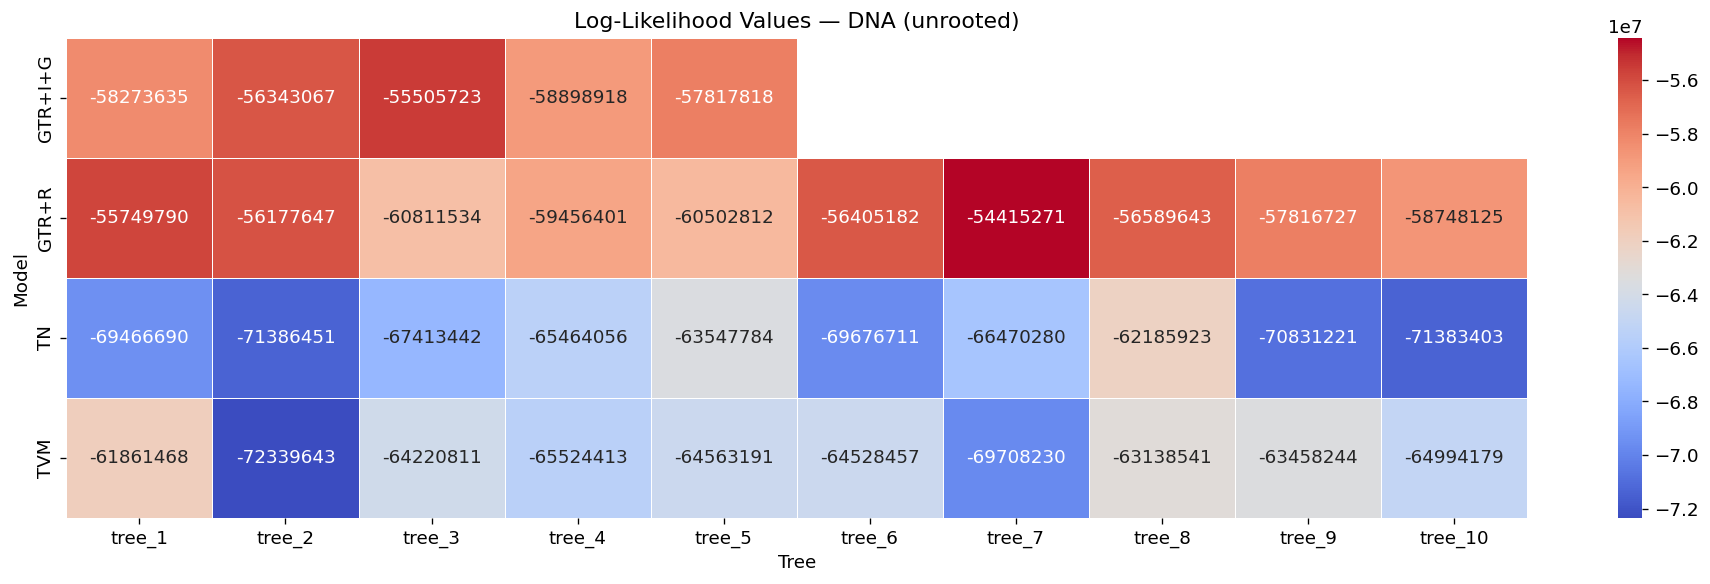

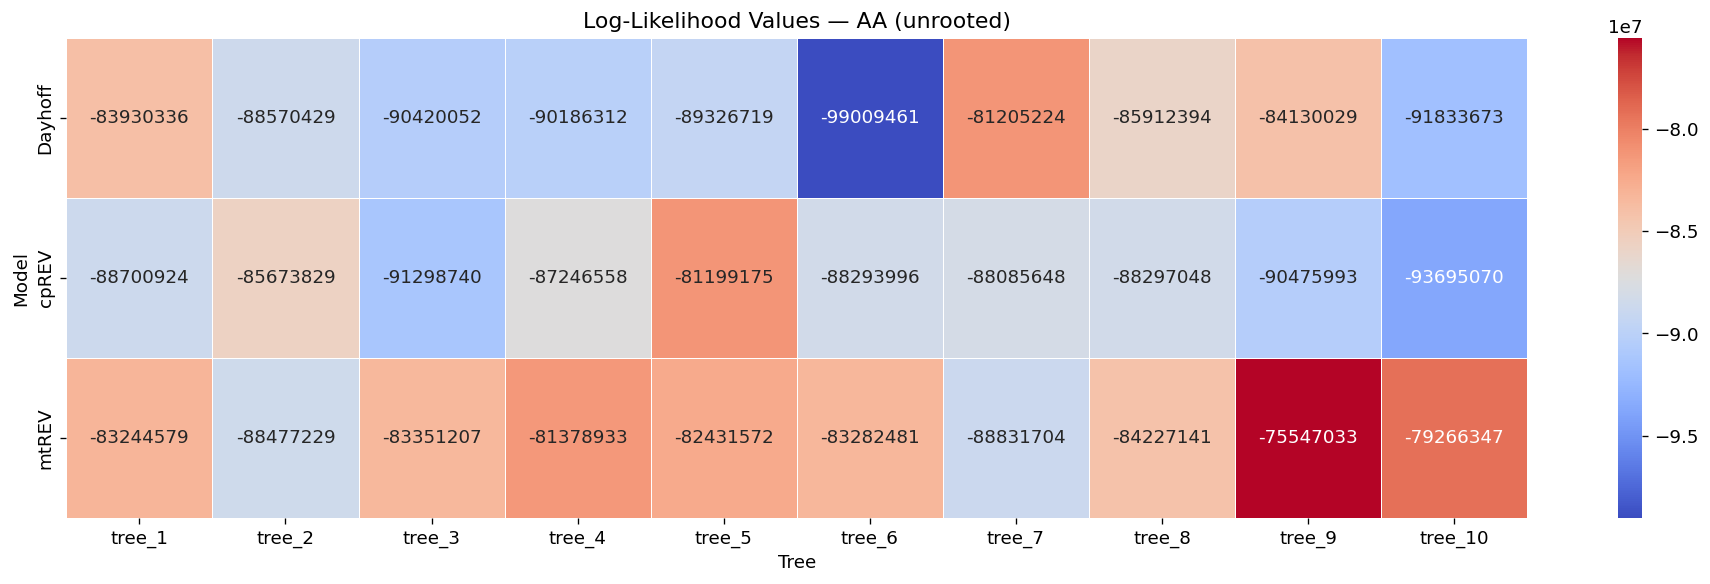

In [26]:
# Likelihood heatmap per model per tree
def plot_likelihood_heatmap(df, data_type, tree_type='unrooted', figsize=(16, 5), path=""):
    subset = df[(df['data_type'] == data_type) & (df['tree_type'] == tree_type)]
    if len(subset) == 0:
        return

    ll_pivot = subset.groupby(['model', 'treefile'])['likelihood'].mean().unstack()
    ll_pivot = ll_pivot[sorted(ll_pivot.columns, key=lambda x: int(re.search(r'\d+', x).group()))]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(ll_pivot, annot=True, fmt='.0f', cmap='coolwarm', ax=ax, linewidths=0.5)
    ax.set_title(f'Log-Likelihood Values — {data_type} ({tree_type})')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Model')
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

for dt in ['DNA', 'AA']:
    plot_likelihood_heatmap(df, dt, path=f"{cwd}/likelihood_heatmap_{dt}.png")

In [27]:
# LL diff heatmap: GPU vs CPU 1-core
def plot_ll_diff_heatmap(ll_means, backend_a, backend_b, figsize=(16, 10), path=""):
    valid = ll_means[[backend_a, backend_b]].dropna()
    if len(valid) == 0:
        print(f"No overlapping data for {backend_a} vs {backend_b}")
        return
    diff = (valid[backend_a] - valid[backend_b]).abs()
    if diff.max() == 0:
        print(f"All likelihoods match perfectly between {backend_a} and {backend_b} — no heatmap needed.")
        return

    diff_df = diff.reset_index()
    diff_df.columns = list(diff_df.columns[:-1]) + ['abs_diff']

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    for (dt, tt), ax in zip(
        [('DNA', 'unrooted'), ('DNA', 'rooted'), ('AA', 'unrooted'), ('AA', 'rooted')],
        axes.flat
    ):
        sub = diff_df[(diff_df['data_type'] == dt) & (diff_df['tree_type'] == tt)]
        if len(sub) == 0:
            ax.set_title(f'{dt} ({tt}) — No data')
            ax.axis('off')
            continue
        pivot = sub.pivot_table(index='model', columns='treefile', values='abs_diff')
        pivot = pivot[sorted(pivot.columns, key=lambda x: int(re.search(r'\d+', x).group()))]
        sns.heatmap(pivot, annot=True, fmt='.6f', cmap='YlOrRd', ax=ax, linewidths=0.5)
        ax.set_title(f'{dt} ({tt})')

    plt.suptitle(f'|LL diff| — {backend_a} vs {backend_b}', fontsize=14, y=1.02)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

if 'IQ-TREE_CPU_1core' in ll_means.columns and 'IQ-TREE_GPU_V100' in ll_means.columns:
    plot_ll_diff_heatmap(ll_means, 'IQ-TREE_GPU_V100', 'IQ-TREE_CPU_1core',
                          path=f"{cwd}/ll_diff_heatmap_gpu_vs_1core.png")

All likelihoods match perfectly between IQ-TREE_GPU_V100 and IQ-TREE_CPU_1core — no heatmap needed.


# 13. Final Summary

In [28]:
print("=" * 80)
print("FINAL SUMMARY: Complex Models Benchmark")
print("=" * 80)

print("\n--- Models with BOTH backends (speedup computable) ---")
both = df.groupby(['data_type', 'model', 'backend']).size().unstack(fill_value=0)
both_complete = both[(both.get('IQ-TREE_CPU_1core', pd.Series(dtype=int)) > 0) &
                     (both.get('IQ-TREE_GPU_V100',  pd.Series(dtype=int)) > 0)]
if len(both_complete) > 0:
    display(both_complete)

print("\n--- Models with GPU ONLY (VANILA failed) ---")
gpu_only_mask = (both.get('IQ-TREE_GPU_V100', pd.Series(dtype=int)) > 0) & \
                (both.get('IQ-TREE_CPU_1core', pd.Series(dtype=int)) == 0)
if gpu_only_mask.any():
    display(both[gpu_only_mask])

print("\n--- Mean Opt-Time Speedup (GPU vs CPU 1-core) ---")
if len(speedup_1core) > 0:
    spd_summary = speedup_1core.groupby(['data_type', 'model'])['speedup_opt'].agg(
        ['mean', 'median']).round(2)
    display(spd_summary)
else:
    print("No speedup data available.")

print("\n--- Failed models (not parseable) ---")
all_models_dna = ['GTR+R', 'GTR+I+G', 'TN', 'TVM']
all_models_aa  = ['Dayhoff', 'mtREV', 'cpREV', 'LG4M', 'C60', 'LG+C60']
parsed_dna = df[df['data_type'] == 'DNA']['model'].unique().tolist()
parsed_aa  = df[df['data_type'] == 'AA']['model'].unique().tolist()
failed_dna = [m for m in all_models_dna if m not in parsed_dna]
failed_aa  = [m for m in all_models_aa  if m not in parsed_aa]
print(f"  DNA failed/missing: {failed_dna}")
print(f"  AA  failed/missing: {failed_aa}")

FINAL SUMMARY: Complex Models Benchmark

--- Models with BOTH backends (speedup computable) ---


backend            IQ-TREE_CPU_1core  IQ-TREE_GPU_V100
data_type model                                       
AA        Dayhoff                200               200
          cpREV                  200               200
          mtREV                  200               200
DNA       TN                     200               200
          TVM                    200               200


--- Models with GPU ONLY (VANILA failed) ---


backend            IQ-TREE_CPU_1core  IQ-TREE_GPU_V100
data_type model                                       
DNA       GTR+I+G                  0               100
          GTR+R                    0               181


--- Mean Opt-Time Speedup (GPU vs CPU 1-core) ---


mean  median
data_type model                 
AA        Dayhoff  38.53   38.81
          cpREV    39.28   39.20
          mtREV    39.53   39.07
DNA       TN       17.20   17.26
          TVM      19.17   19.08


--- Failed models (not parseable) ---
  DNA failed/missing: []
  AA  failed/missing: ['LG4M', 'C60', 'LG+C60']
